In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
experiment: dict[str, dict[str, dict[float, float]]] = \
    {
  "tension_distribution": {
    "short_circuit": { # закрытый со стоячей волной
        19.65: 0,
        19: 8,
        20: 180,
        21: 368,
        22: 490,
        23: 544,
        24: 506,
        25: 378,
        26: 194,
        27: 20,
        28: 0,
        28.25: 0,
        36.75: 0,
        45.25: 0
    },
    "open": { # открытый со стоячей волной
        13: 152,
        14: 142,
        15: 154,
        16: 200,
        17: 240,
        18: 260,
        19: 250,
        20: 216,
        21: 170,
        22: 136,
        23: 144
    }
  },
  "radiation_pattern": {
    "megaphone": { # рупор
      0: 708,
      10: 616,
      20: 264,
      30: 112,
      40: 40,
      50: 24,
      60: 0
    },
    "open_waveguide": { # открытый волновод
      0: 201,
      10: 180,
      20: 153,
      30: 116,
      40: 89,
      50: 57,
      60: 22,
      70: 15,
      80: 17,
      90: 12,
      115: 0
    },
    "with_dielectric": { # с диэлектриком
      11: 110,
      12: 112,
      13: 176,
      14: 258,
      15: 314,
      16: 334,
      17: 298,
      18: 234,
      19: 154,
      20: 104
    }
  },
  "polarization": {
    "gauze": { # сетка
      0: 56,
      10: 60,
      20: 60,
      30: 108,
      40: 224,
      50: 336,
      60: 440,
      70: 484,
      80: 552,
      90: 556,
      100: 532,
      110: 492,
      120: 420,
      130: 328,
      140: 244,
      150: 140,
      160: 52,
      170: 52,
      180: 56
    }
  },
  "total_internal_reflection": {
    "prism": { # призма
        0: 338,
        1: 312,
        2: 242,
        3: 210,
        4: 188,
        5: 152,
        6: 98,
        7: 66,
        8: 36,
        9: 24,
        10: 16,
        11: 0
    }
  }
}

In [ ]:
A_max = 260 # максимальное значение напряженности в случае стоячей волны (открытое состояние)
A_min = 142 # минимальное значение напряженности в случае стоячей волны (открытое состояние)

print(f"КСВН = {(np.sqrt(A_max / A_min)):.5f}")


КСВН = 1.35314


In [19]:
tension_distribution_open = list(experiment["tension_distribution"]["open"].values())

tension_distribution_open_KSVN = np.sqrt(
    max(tension_distribution_open) / min(tension_distribution_open))
print("КСВН = ", tension_distribution_open_KSVN)

tension_distribution_open_RO = (tension_distribution_open_KSVN - 1) / \
    (tension_distribution_open_KSVN + 1)
print("RO = ", tension_distribution_open_RO) # коэфф отражения

КСВН =  1.3826657968874305
RO =  0.1606040584404753


In [21]:
eps = 1 / tension_distribution_open_KSVN # коэффициент бегущей волны
print("КБВ = ", float(eps))

КБВ =  0.7232405706795789


In [ ]:
import numpy as np

# Исходные данные
c = 3e8          # скорость света, м/с
f = 3e10         # частота, Гц
Z0 = 377         # импеданс свободного пространства, Ом
lam = c / f      # длина волны в воздухе, м

print(f"Длина волны в воздухе: λ = {lam*1e3:.1f} мм")
print("=" * 50)

# Два волновода
waveguides = {
    "11 × 5.5 мм": {"a": 11e-3, "b": 5.5e-3},
}

for name, params in waveguides.items():
    a = params["a"]
    b = params["b"]
    
    # Критическая длина волны lambda_cr = 2a
    lam_cr = 2 * a
    
    
    # Отношение lambda / 2a
    ratio = lam / (2 * a)
    
    # Волновое сопротивление волновода
    Z_wg = Z0 / np.sqrt(1 - ratio**2)
    
    # Длина волны в волноводе
    lam_wg = lam / np.sqrt(1 - ratio**2)
    
    # Коэффициент отражения 
    rho = (Z0 - Z_wg) / (Z0 + Z_wg)
    
    # КСВН
    KSVN = (1 + abs(rho)) / (1 - abs(rho))
    
    print(f"\nВолновод {name}:")
    print(f"  λ/(2a) = {ratio:.3f}")
    print(f"  λ_кр = 2a = {lam_cr*1e3:.1f} мм")
    print(f"  Z_волновода = {Z_wg:.1f} Ом")
    print(f"  λ_в волноводе = {lam_wg*1e3:.2f} мм")
    print(f"  ρ = {rho:.4f}")
    print(f"  |ρ| = {abs(rho):.4f}")
    print(f"  |ρ|² = {abs(rho)**2:.4f}")
    print(f"  КСВН = {KSVN:.2f}")
    print(f"  Доля отражённой мощности = {abs(rho)**2*100:.2f}%")
    print(f"  Доля прошедшей мощности = {(1-abs(rho)**2)*100:.2f}%")
    print("\n" + "=" * 50)

    

Длина волны в воздухе: λ = 10.0 мм

Волновод 11 × 5.5 мм:
  λ/(2a) = 0.455
  λ_кр = 2a = 22.0 мм
  Z_волновода = 423.3 Ом
  λ_в волноводе = 11.23 мм
  ρ = -0.0578
  |ρ| = 0.0578
  |ρ|² = 0.0033
  КСВН = 1.12
  Доля отражённой мощности = 0.33%
  Доля прошедшей мощности = 99.67%



Длина волны в воздухе: λ = 10.0 мм

--- Грубая оценка (формулы Френеля) ---

Материал            ε     √ε        ρ    |ρ|²   КСВН
-------------------------------------------------------
Эбонит            4.0   2.00  -0.3333  0.1111   2.00


--- Точный расчёт (с учётом волновода) ---

Волновод 11 × 5.5 мм:
  λ/(2a) = 0.455
  Z_пустой = 423.3 Ом

      ε   Z_диэл, Ом   ρ_волновод    ρ_Френель    КСВН
  -------------------------------------------------------
    2.0        281.5      -0.2011      -0.1716    1.50
    4.0        193.6      -0.3724      -0.3333    2.19
    9.0        127.1      -0.5380      -0.5000    3.33
   16.0         94.9      -0.6338      -0.6000    4.46


--- Обратная задача: КСВН → ε ---

Пример: как в лабе определяют ε по измерениям

  КСВН     |ρ|   ε (Френель)     √ε
----------------------------------------
   1.5  0.2000          2.25   1.50
   2.0  0.3333          4.00   2.00
   3.0  0.5000          9.00   3.00
   5.0  0.6667         25.00   5.00
   8.0  0.7778 

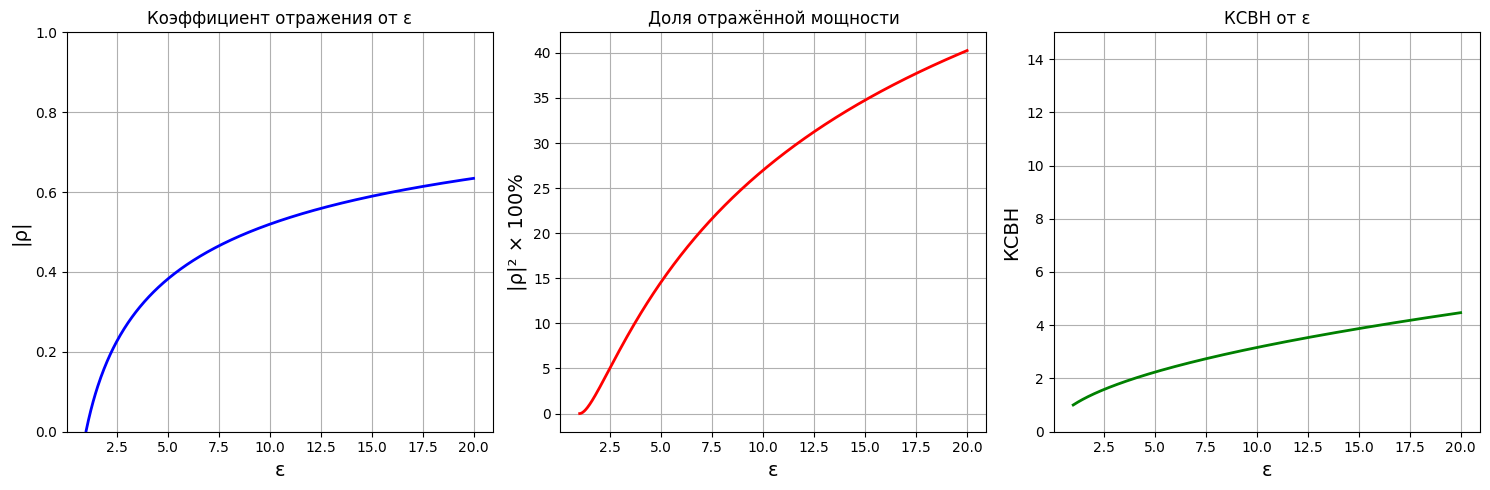


График сохранён: reflection_vs_epsilon.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Исходные данные
# ============================================================
c = 3e8          # скорость света, м/с
f = 3e10         # частота, Гц
Z0 = 377         # импеданс свободного пространства, Ом
lam = c / f      # длина волны в воздухе, м

print(f"Длина волны в воздухе: λ = {lam*1e3:.1f} мм")
print("=" * 60)

# Два волновода
waveguides = {
    "11 × 5.5 мм": {"a": 11e-3, "b": 5.5e-3},
}

# Диапазон диэлектрических проницаемостей для расчёта
eps_array = np.linspace(1.1, 20, 200)

# ============================================================
# 1. Грубая оценка (просто Френель, как для плоской волны)
# ============================================================
print("\n--- Грубая оценка (формулы Френеля) ---\n")

# Примеры типичных диэлектриков
materials = {
    "Эбонит":      4,
}

print(f"{'Материал':<15} {'ε':>5} {'√ε':>6} {'ρ':>8} {'|ρ|²':>7} {'КСВН':>6}")
print("-" * 55)

for mat, eps in materials.items():
    n = np.sqrt(eps)
    rho = (1 - n) / (1 + n)
    KSVN = (1 + abs(rho)) / (1 - abs(rho))
    print(f"{mat:<15} {eps:>5.1f} {n:>6.2f} {rho:>8.4f} {abs(rho)**2:>7.4f} {KSVN:>6.2f}")

# ============================================================
# 2. Точный расчёт с учётом волновода
# ============================================================
print("\n\n--- Точный расчёт (с учётом волновода) ---\n")

for wg_name, params in waveguides.items():
    a = params["a"]
    
    lam_cr = 2 * a  # критическая длина волны
    
    if lam >= lam_cr:
        print(f"Волновод {wg_name}: волна не распространяется!")
        continue
    
    ratio = lam / (2 * a)  # λ/(2a)
    
    # Волновое сопротивление пустого волновода
    Z_empty = Z0 / np.sqrt(1 - ratio**2)
    
    print(f"Волновод {wg_name}:")
    print(f"  λ/(2a) = {ratio:.3f}")
    print(f"  Z_пустой = {Z_empty:.1f} Ом")
    print()
    print(f"  {'ε':>5} {'Z_диэл, Ом':>12} {'ρ_волновод':>12} {'ρ_Френель':>12} {'КСВН':>7}")
    print("  " + "-" * 55)
    
    for eps in [2.0, 4.0, 9.0, 16.0]:
        n = np.sqrt(eps)
        
        # Длина волны в среде
        lam_medium = lam / n
        
        # Проверка: распространяется ли волна в заполненном волноводе
        ratio_medium = lam_medium / (2 * a)
        
        if ratio_medium >= 1:
            print(f"  {eps:>5.1f}   волна не распространяется в диэлектрике!")
            continue
        
        # Волновое сопротивление заполненного волновода
        Z_medium = (Z0 / n) / np.sqrt(1 - ratio_medium**2)
        
        # Коэффициент отражения в волноводе
        rho_wg = (Z_medium - Z_empty) / (Z_medium + Z_empty)
        
        # Коэффициент отражения по Френелю (без учёта волновода)
        rho_fr = (1 - n) / (1 + n)
        
        KSVN = (1 + abs(rho_wg)) / (1 - abs(rho_wg))
        
        print(f"  {eps:>5.1f} {Z_medium:>12.1f} {rho_wg:>12.4f} {rho_fr:>12.4f} {KSVN:>7.2f}")
    
    print()

# ============================================================
# 3. Обратная задача: из КСВН найти ε
# ============================================================
print("\n--- Обратная задача: КСВН → ε ---\n")
print("Пример: как в лабе определяют ε по измерениям\n")

# Пример измеренных КСВН
KSVN_measured = [1.5, 2.0, 3.0, 5.0, 8.0]

print(f"{'КСВН':>6} {'|ρ|':>7} {'ε (Френель)':>13} {'√ε':>6}")
print("-" * 40)

for K in KSVN_measured:
    rho_abs = (K - 1) / (K + 1)
    n = (1 + rho_abs) / (1 - rho_abs)
    eps = n**2
    print(f"{K:>6.1f} {rho_abs:>7.4f} {eps:>13.2f} {n:>6.2f}")

# ============================================================
# 4. График: ρ и КСВН от ε
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# а) Коэффициент отражения
eps_plot = np.linspace(1.01, 20, 500)
n_plot = np.sqrt(eps_plot)
rho_plot = (1 - n_plot) / (1 + n_plot)
axes[0].plot(eps_plot, np.abs(rho_plot), 'b-', linewidth=2)
axes[0].set_xlabel('ε', fontsize=14)
axes[0].set_ylabel('|ρ|', fontsize=14)
axes[0].set_title('Коэффициент отражения от ε')
axes[0].grid(True)
axes[0].set_ylim(0, 1)

# б) Отражённая мощность
axes[1].plot(eps_plot, np.abs(rho_plot)**2 * 100, 'r-', linewidth=2)
axes[1].set_xlabel('ε', fontsize=14)
axes[1].set_ylabel('|ρ|² × 100%', fontsize=14)
axes[1].set_title('Доля отражённой мощности')
axes[1].grid(True)

# в) КСВН
KSVN_plot = (1 + np.abs(rho_plot)) / (1 - np.abs(rho_plot))
axes[2].plot(eps_plot, KSVN_plot, 'g-', linewidth=2)
axes[2].set_xlabel('ε', fontsize=14)
axes[2].set_ylabel('КСВН', fontsize=14)
axes[2].set_title('КСВН от ε')
axes[2].grid(True)
axes[2].set_ylim(0, 15)

plt.tight_layout()
plt.savefig('reflection_vs_epsilon.png', dpi=150)
plt.show()

print("\nГрафик сохранён: reflection_vs_epsilon.png")

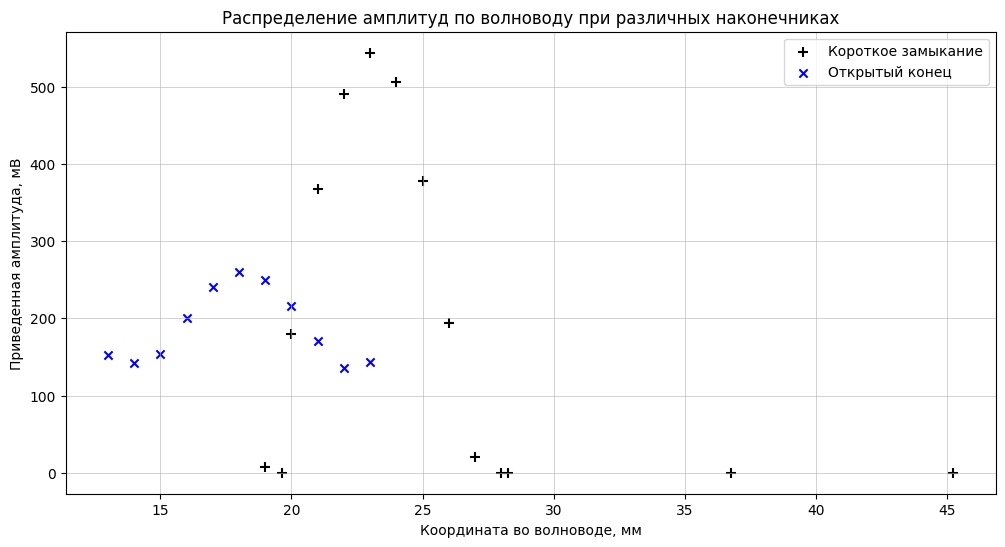

In [22]:
_, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.scatter(np.array(list(experiment["tension_distribution"]["short_circuit"].keys())),
           np.array(list(experiment["tension_distribution"]["short_circuit"].values())),
           marker="+",
           s=45,
           label="Короткое замыкание",
           color="black")

ax.scatter(np.array(list(experiment["tension_distribution"]["open"].keys())),
           np.array(list(experiment["tension_distribution"]["open"].values())),
           marker="x",
           s=35,
           label="Открытый конец",
           color="blue")

ax.set_title("Распределение амплитуд по волноводу при различных наконечниках")
ax.set_ylabel("Приведенная амплитуда, мВ")
ax.set_xlabel("Координата во волноводе, мм")


plt.grid(which='minor', linestyle='--', linewidth=0.2)
plt.grid(which='major', linewidth=0.4)

plt.legend()
plt.show()

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import argrelextrema

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [24]:
experiment = {
    "tension_distribution": {
        "short_circuit": {
            19.65: 0, 19: 8, 20: 180, 21: 368, 22: 490,
            23: 544, 24: 506, 25: 378, 26: 194, 27: 20,
            28: 0, 28.25: 0, 36.75: 0, 45.25: 0
        },
        "open": {
            13: 152, 14: 142, 15: 154, 16: 200, 17: 240,
            18: 260, 19: 250, 20: 216, 21: 170, 22: 136, 23: 144
        }
    },
    "radiation_pattern": {
        "megaphone": {
            0: 708, 10: 616, 20: 264, 30: 112, 40: 40, 50: 24, 60: 0
        },
        "open_waveguide": {
            0: 201, 10: 180, 20: 153, 30: 116, 40: 89,
            50: 57, 60: 22, 70: 15, 80: 17, 90: 12, 115: 0
        },
        "with_dielectric": {
            11: 110, 12: 112, 13: 176, 14: 258, 15: 314,
            16: 334, 17: 298, 18: 234, 19: 154, 20: 104
        }
    },
    "polarization": {
        "gauze": {
            0: 56, 10: 60, 20: 60, 30: 108, 40: 224,
            50: 336, 60: 440, 70: 484, 80: 552, 90: 556,
            100: 532, 110: 492, 120: 420, 130: 328, 140: 244,
            150: 140, 160: 52, 170: 52, 180: 56
        }
    },
    "total_internal_reflection": {
        "prism": {
            0: 338, 1: 312, 2: 242, 3: 210, 4: 188,
            5: 152, 6: 98, 7: 66, 8: 36, 9: 24, 10: 16, 11: 0
        }
    }
}

print("Данные загружены ✓")

Данные загружены ✓


In [48]:
# === Параметры установки ===
f = 2.784e10              # Частота, Гц
c = 3e8               # Скорость света, м/с
lam0 = c / f          # Длина волны в воздухе, м
lam0_mm = lam0 * 1e3  # мм

# Размеры волноводов a×b (мм)
waveguides = {
    "7.2×3.4": (7.2, 3.4),
    "11×5.5":  (11.0, 5.5),
}

print(f"Частота:            f  = {f:.2e} Гц")
print(f"Длина волны (воздух): λ₀ = {lam0_mm:.2f} мм")
print()

# === Вспомогательные функции ===

def calc_vswr(A_max, A_min):
    """КСВН из показаний квадратичного детектора."""
    if A_min == 0:
        return np.inf, 1.0
    vswr = np.sqrt(A_max / A_min)
    rho = (vswr - 1) / (vswr + 1)
    return vswr, rho


def lam_waveguide_theory(lam0_mm, a_mm):
    """Теоретическая λ_в для моды H₁₀: λ_кр = 2a."""
    lam_cr = 2 * a_mm
    if lam0_mm >= lam_cr:
        return None, lam_cr
    lam_wg = lam0_mm / np.sqrt(1 - (lam0_mm / lam_cr)**2)
    return lam_wg, lam_cr


# Проверка: какие волноводы пропускают волну
for name, (a, b) in waveguides.items():
    lam_wg, lam_cr = lam_waveguide_theory(lam0_mm, a)
    status = f"λ_в = {lam_wg:.2f} мм" if lam_wg else "НЕ распространяется"
    print(f"Волновод {name} мм:  λ_кр = {lam_cr:.1f} мм  →  {status}")

Частота:            f  = 2.78e+10 Гц
Длина волны (воздух): λ₀ = 10.78 мм

Волновод 7.2×3.4 мм:  λ_кр = 14.4 мм  →  λ_в = 16.25 мм
Волновод 11×5.5 мм:  λ_кр = 22.0 мм  →  λ_в = 12.36 мм


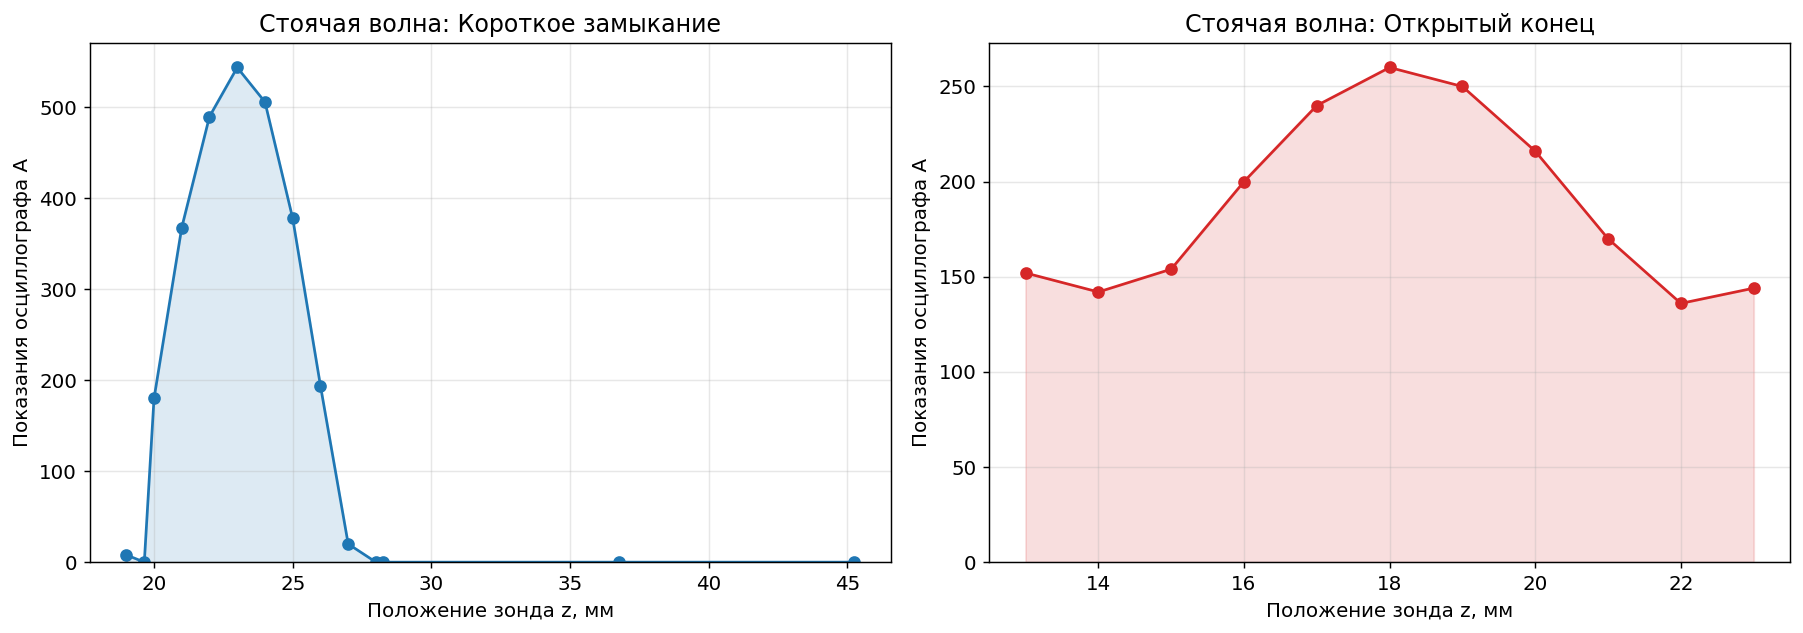

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

titles = {"short_circuit": "Короткое замыкание", "open": "Открытый конец"}
colors = {"short_circuit": "tab:blue", "open": "tab:red"}

for ax, (load, data) in zip(axes, experiment["tension_distribution"].items()):
    pos = np.array(sorted(data.keys()))
    amp = np.array([data[p] for p in pos])
    
    ax.plot(pos, amp, 'o-', color=colors[load], ms=6, lw=1.5)
    ax.fill_between(pos, amp, alpha=0.15, color=colors[load])
    ax.set_xlabel("Положение зонда z, мм")
    ax.set_ylabel("Показания осциллографа A")
    ax.set_title(f"Стоячая волна: {titles[load]}")
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

In [50]:
print("=" * 60)
print("КОРОТКОЕ ЗАМЫКАНИЕ")
print("=" * 60)

data_sc = experiment["tension_distribution"]["short_circuit"]
pos_sc = np.array(sorted(data_sc.keys()))
amp_sc = np.array([data_sc[p] for p in pos_sc])

# --- Позиции нулей ---
zeros = pos_sc[amp_sc == 0]
print(f"\nПозиции нулей: {zeros} мм")

dz = np.diff(zeros)
print(f"Расстояния между соседними нулями (= λ_в/2): {dz} мм")

lam_wg_exp_sc = 2 * np.mean(dz)
print(f"\nДлина волны в волноводе (эксп.): λ_в = 2·<Δz> = {lam_wg_exp_sc:.2f} мм")

# --- КСВН ---
A_max_sc = amp_sc.max()
A_min_sc = amp_sc.min()
vswr_sc, rho_sc = calc_vswr(A_max_sc, A_min_sc)

print(f"\nA_max = {A_max_sc},  A_min = {A_min_sc}")
print(f"КСВН_эксп = √(A_max/A_min) = {'∞' if vswr_sc == np.inf else f'{vswr_sc:.2f}'}")
print(f"|ρ|_эксп = {rho_sc:.4f}")

# --- Теоретическое КСВН ---
# КЗ: идеальное отражение, ρ = -1, |ρ| = 1, КСВН = ∞
print(f"\nТеория (идеальное КЗ): |ρ| = 1.000, КСВН = ∞")

# --- Сравнение λ_в ---
print(f"\n{'Волновод':<12} {'λ_кр, мм':>10} {'λ_в теор, мм':>14} {'λ_в эксп, мм':>14} {'Δ, %':>8}")
print("-" * 62)
for name, (a, b) in waveguides.items():
    lam_wg_th, lam_cr = lam_waveguide_theory(lam0_mm, a)
    if lam_wg_th:
        delta = abs(lam_wg_exp_sc - lam_wg_th) / lam_wg_th * 100
        print(f"{name:<12} {lam_cr:>10.1f} {lam_wg_th:>14.2f} {lam_wg_exp_sc:>14.2f} {delta:>8.1f}")
    else:
        print(f"{name:<12} {lam_cr:>10.1f} {'—':>14} {lam_wg_exp_sc:>14.2f} {'—':>8}")

КОРОТКОЕ ЗАМЫКАНИЕ

Позиции нулей: [19.65 28.   28.25 36.75 45.25] мм
Расстояния между соседними нулями (= λ_в/2): [8.35 0.25 8.5  8.5 ] мм

Длина волны в волноводе (эксп.): λ_в = 2·<Δz> = 12.80 мм

A_max = 544,  A_min = 0
КСВН_эксп = √(A_max/A_min) = ∞
|ρ|_эксп = 1.0000

Теория (идеальное КЗ): |ρ| = 1.000, КСВН = ∞

Волновод       λ_кр, мм   λ_в теор, мм   λ_в эксп, мм     Δ, %
--------------------------------------------------------------
7.2×3.4            14.4          16.25          12.80     21.2
11×5.5             22.0          12.36          12.80      3.6


In [41]:
print("=" * 60)
print("ОТКРЫТЫЙ КОНЕЦ ВОЛНОВОДА")
print("=" * 60)

data_op = experiment["tension_distribution"]["open"]
pos_op = np.array(sorted(data_op.keys()))
amp_op = np.array([data_op[p] for p in pos_op])

A_max_op = amp_op.max()
A_min_op = amp_op.min()
vswr_op, rho_op = calc_vswr(A_max_op, A_min_op)

print(f"\nA_max = {A_max_op},  A_min = {A_min_op}")
print(f"КСВН_эксп = √({A_max_op}/{A_min_op}) = {vswr_op:.3f}")
print(f"|ρ|_эксп = {rho_op:.4f}")

# --- Теоретическое КСВН для открытого конца ---
# Открытый конец прямоугольного волновода:
# Приближённая формула для коэффициента отражения (H10 мода):
#   |ρ| ≈ 1 для узкого волновода (a << λ₀ → полное отражение)
#   |ρ| < 1 для широкого волновода (a ~ λ₀ → частичное излучение)
#
# Точная оценка: эквивалентный импеданс открытого конца волновода
# Z_load = Z_radiation (импеданс излучения)
# Для прямоугольного волновода моды H10:
#   Z_волновода = Z₀ · λ_в / λ₀, где Z₀ = 120π ≈ 377 Ом
#   Z_свободного_пр-ва = Z₀ = 377 Ом
#
# Простейшая модель: рассогласование волновод—свободное пр-во
# ρ_теор = (Z_load - Z_wg) / (Z_load + Z_wg)

print("\n--- Теоретическая оценка КСВН (открытый конец) ---")
print("Модель: рассогласование импедансов волновод ↔️ свободное пространство")

for wg_name, (a, b) in waveguides.items():
    lam_wg_th, lam_cr = lam_waveguide_theory(lam0_mm, a)
    if lam_wg_th is None:
        continue
    
    Z0 = 377.0  # Ом, импеданс свободного пространства
    # Волноводный импеданс для моды H10:
    #   Z_wg = Z₀ / √(1 - (λ₀/2a)²) = Z₀ · (λ_в / λ₀)
    Z_wg = Z0 * lam_wg_th / lam0_mm
    
    # Импеданс нагрузки ≈ Z₀ (упрощённо — свободное пространство)
    Z_load = Z0
    
    rho_theor = abs(Z_load - Z_wg) / (Z_load + Z_wg)
    vswr_theor = (1 + rho_theor) / (1 - rho_theor)
    
    print(f"\n  Волновод {wg_name} мм:")
    print(f"    Z_wg = Z₀·(λ_в/λ₀) = 377·({lam_wg_th:.2f}/{lam0_mm:.2f}) = {Z_wg:.1f} Ом")
    print(f"    Z_load ≈ Z₀ = {Z_load:.0f} Ом")
    print(f"    |ρ|_теор = |Z_load − Z_wg| / (Z_load + Z_wg) = {rho_theor:.4f}")
    print(f"    КСВН_теор = (1+|ρ|)/(1−|ρ|) = {vswr_theor:.3f}")

print(f"\n  Сравнение:")
print(f"    |ρ|_эксп  = {rho_op:.4f}")
print(f"    КСВН_эксп = {vswr_op:.3f}")

# Поиск минимумов и максимумов
idx_mins = argrelextrema(amp_op, np.less_equal, order=1)[0]
pos_mins = pos_op[idx_mins]
idx_maxs = argrelextrema(amp_op, np.greater_equal, order=1)[0]
pos_maxs = pos_op[idx_maxs]

print(f"\nПозиции минимумов: {pos_mins} мм")
print(f"Позиции максимумов: {pos_maxs} мм")
if len(pos_mins) >= 2:
    dz_op = np.diff(pos_mins)
    lam_wg_exp_op = 2 * np.mean(dz_op)
    print(f"λ_в (по мин.) = {lam_wg_exp_op:.2f} мм")
if len(pos_maxs) >= 2:
    dz_max_op = np.diff(pos_maxs)
    lam_wg_exp_op2 = 2 * np.mean(dz_max_op)
    print(f"λ_в (по макс.) = {lam_wg_exp_op2:.2f} мм")

ОТКРЫТЫЙ КОНЕЦ ВОЛНОВОДА

A_max = 260,  A_min = 136
КСВН_эксп = √(260/136) = 1.383
|ρ|_эксп = 0.1606

--- Теоретическая оценка КСВН (открытый конец) ---
Модель: рассогласование импедансов волновод ↔️ свободное пространство

  Волновод 7.2×3.4 мм:
    Z_wg = Z₀·(λ_в/λ₀) = 377·(13.90/10.00) = 523.9 Ом
    Z_load ≈ Z₀ = 377 Ом
    |ρ|_теор = |Z_load − Z_wg| / (Z_load + Z_wg) = 0.1631
    КСВН_теор = (1+|ρ|)/(1−|ρ|) = 1.390

  Волновод 11×5.5 мм:
    Z_wg = Z₀·(λ_в/λ₀) = 377·(11.23/10.00) = 423.3 Ом
    Z_load ≈ Z₀ = 377 Ом
    |ρ|_теор = |Z_load − Z_wg| / (Z_load + Z_wg) = 0.0578
    КСВН_теор = (1+|ρ|)/(1−|ρ|) = 1.123

  Сравнение:
    |ρ|_эксп  = 0.1606
    КСВН_эксп = 1.383

Позиции минимумов: [14 22] мм
Позиции максимумов: [13 18 23] мм
λ_в (по мин.) = 16.00 мм
λ_в (по макс.) = 10.00 мм


In [42]:
print("=" * 80)
print("СВОДНАЯ ТАБЛИЦА КСВН: ЭКСПЕРИМЕНТ vs ТЕОРИЯ")
print("=" * 80)

# Теоретические значения для каждого типа нагрузки
# Выбираем волновод (подставьте нужный)
a_used, b_used = 11.0, 5.5  # мм — используемый волновод
lam_wg_used, lam_cr_used = lam_waveguide_theory(lam0_mm, a_used)
Z0 = 377.0
Z_wg_used = Z0 * lam_wg_used / lam0_mm if lam_wg_used else None

print(f"Используемый волновод: {a_used}×{b_used} мм")
print(f"  λ_в = {lam_wg_used:.2f} мм,  Z_wg = {Z_wg_used:.1f} Ом")
print()

def theoretical_vswr(load_type, Z_wg, Z0):
    """
    Теоретический КСВН для различных нагрузок.
    
    КЗ:           Z_L = 0        → ρ = -1     → КСВН = ∞
    Согласованная: Z_L = Z_wg    → ρ = 0      → КСВН = 1
    Открытый:      Z_L ≈ Z₀      → ρ = ...    → КСВН = ...
    """
    if load_type == "short_circuit":
        # Идеальное КЗ: Z_L = 0
        Z_L = 0
        rho = -1.0
        vswr = np.inf
        return vswr, abs(rho), Z_L, "Z_L = 0 (идеальный проводник)"
    
    elif load_type == "matched":
        # Согласованная нагрузка: Z_L = Z_wg
        Z_L = Z_wg
        rho = 0.0
        vswr = 1.0
        return vswr, abs(rho), Z_L, f"Z_L = Z_wg = {Z_wg:.1f} Ом"
    
    elif load_type == "open":
        # Открытый конец: Z_L ≈ Z₀ (свободное пространство)
        Z_L = Z0
        rho = (Z_L - Z_wg) / (Z_L + Z_wg)
        vswr = (1 + abs(rho)) / (1 - abs(rho))
        return vswr, abs(rho), Z_L, f"Z_L ≈ Z₀ = {Z0:.0f} Ом"
    
    else:
        return None, None, None, "Нет теор. модели"


# Таблица
header = (f"{'Нагрузка':<20} │ {'A_max':>6} {'A_min':>6} │ "
          f"{'КСВН_эксп':>10} {'|ρ|_эксп':>9} │ "
          f"{'КСВН_теор':>10} {'|ρ|_теор':>9} │ {'Δ|ρ|':>6}")
print(header)
print("─" * len(header))

loads_theory = {
    "short_circuit": "short_circuit",
    "open": "open",
}

for load, data in experiment["tension_distribution"].items():
    pos = np.array(sorted(data.keys()))
    amp = np.array([data[p] for p in pos])
    
    Amax = amp.max()
    Amin = amp.min()
    vswr_exp, rho_exp = calc_vswr(Amax, Amin)
    vswr_exp_s = "∞" if vswr_exp == np.inf else f"{vswr_exp:.3f}"
    
    # Теория
    load_type = loads_theory.get(load, load)
    vswr_th, rho_th, Z_L, note = theoretical_vswr(load_type, Z_wg_used, Z0)
    
    if vswr_th is not None:
        vswr_th_s = "∞" if vswr_th == np.inf else f"{vswr_th:.3f}"
        if rho_th is not None and rho_exp is not None:
            delta_rho = abs(rho_exp - rho_th)
            delta_s = f"{delta_rho:.4f}"
        else:
            delta_s = "—"
    else:
        vswr_th_s = "—"
        rho_th = None
        delta_s = "—"
    
    rho_th_s = f"{rho_th:.4f}" if rho_th is not None else "—"
    
    print(f"{load:<20} │ {Amax:>6.0f} {Amin:>6.0f} │ "
          f"{vswr_exp_s:>10} {rho_exp:>9.4f} │ "
          f"{vswr_th_s:>10} {rho_th_s:>9} │ {delta_s:>6}")

print()
print("Примечания к теоретическим значениям:")
for load in loads_theory:
    _, _, Z_L, note = theoretical_vswr(loads_theory[load], Z_wg_used, Z0)
    print(f"  {load:<20}: {note}")

СВОДНАЯ ТАБЛИЦА КСВН: ЭКСПЕРИМЕНТ vs ТЕОРИЯ
Используемый волновод: 11.0×5.5 мм
  λ_в = 11.23 мм,  Z_wg = 423.3 Ом

Нагрузка             │  A_max  A_min │  КСВН_эксп  |ρ|_эксп │  КСВН_теор  |ρ|_теор │   Δ|ρ|
───────────────────────────────────────────────────────────────────────────────────────────
short_circuit        │    544      0 │          ∞    1.0000 │          ∞    1.0000 │ 0.0000
open                 │    260    136 │      1.383    0.1606 │      1.123    0.0578 │ 0.1028

Примечания к теоретическим значениям:
  short_circuit       : Z_L = 0 (идеальный проводник)
  open                : Z_L ≈ Z₀ = 377 Ом


In [43]:
print("=" * 80)
print("СВОДНАЯ ТАБЛИЦА КСВН: ЭКСПЕРИМЕНТ vs ТЕОРИЯ")
print("=" * 80)

# Теоретические значения для каждого типа нагрузки
# Выбираем волновод (подставьте нужный)
a_used, b_used = 11.0, 5.5  # мм — используемый волновод
lam_wg_used, lam_cr_used = lam_waveguide_theory(lam0_mm, a_used)
Z0 = 377.0
Z_wg_used = Z0 * lam_wg_used / lam0_mm if lam_wg_used else None

print(f"Используемый волновод: {a_used}×{b_used} мм")
print(f"  λ_в = {lam_wg_used:.2f} мм,  Z_wg = {Z_wg_used:.1f} Ом")
print()

def theoretical_vswr(load_type, Z_wg, Z0):
    """
    Теоретический КСВН для различных нагрузок.
    
    КЗ:           Z_L = 0        → ρ = -1     → КСВН = ∞
    Согласованная: Z_L = Z_wg    → ρ = 0      → КСВН = 1
    Открытый:      Z_L ≈ Z₀      → ρ = ...    → КСВН = ...
    """
    if load_type == "short_circuit":
        # Идеальное КЗ: Z_L = 0
        Z_L = 0
        rho = -1.0
        vswr = np.inf
        return vswr, abs(rho), Z_L, "Z_L = 0 (идеальный проводник)"
    
    elif load_type == "matched":
        # Согласованная нагрузка: Z_L = Z_wg
        Z_L = Z_wg
        rho = 0.0
        vswr = 1.0
        return vswr, abs(rho), Z_L, f"Z_L = Z_wg = {Z_wg:.1f} Ом"
    
    elif load_type == "open":
        # Открытый конец: Z_L ≈ Z₀ (свободное пространство)
        Z_L = Z0
        rho = (Z_L - Z_wg) / (Z_L + Z_wg)
        vswr = (1 + abs(rho)) / (1 - abs(rho))
        return vswr, abs(rho), Z_L, f"Z_L ≈ Z₀ = {Z0:.0f} Ом"
    
    else:
        return None, None, None, "Нет теор. модели"


# Таблица
header = (f"{'Нагрузка':<20} │ {'A_max':>6} {'A_min':>6} │ "
          f"{'КСВН_эксп':>10} {'|ρ|_эксп':>9} │ "
          f"{'КСВН_теор':>10} {'|ρ|_теор':>9} │ {'Δ|ρ|':>6}")
print(header)
print("─" * len(header))

loads_theory = {
    "short_circuit": "short_circuit",
    "open": "open",
}

for load, data in experiment["tension_distribution"].items():
    pos = np.array(sorted(data.keys()))
    amp = np.array([data[p] for p in pos])
    
    Amax = amp.max()
    Amin = amp.min()
    vswr_exp, rho_exp = calc_vswr(Amax, Amin)
    vswr_exp_s = "∞" if vswr_exp == np.inf else f"{vswr_exp:.3f}"
    
    # Теория
    load_type = loads_theory.get(load, load)
    vswr_th, rho_th, Z_L, note = theoretical_vswr(load_type, Z_wg_used, Z0)
    
    if vswr_th is not None:
        vswr_th_s = "∞" if vswr_th == np.inf else f"{vswr_th:.3f}"
        if rho_th is not None and rho_exp is not None:
            delta_rho = abs(rho_exp - rho_th)
            delta_s = f"{delta_rho:.4f}"
        else:
            delta_s = "—"
    else:
        vswr_th_s = "—"
        rho_th = None
        delta_s = "—"
    
    rho_th_s = f"{rho_th:.4f}" if rho_th is not None else "—"
    
    print(f"{load:<20} │ {Amax:>6.0f} {Amin:>6.0f} │ "
          f"{vswr_exp_s:>10} {rho_exp:>9.4f} │ "
          f"{vswr_th_s:>10} {rho_th_s:>9} │ {delta_s:>6}")

print()
print("Примечания к теоретическим значениям:")
for load in loads_theory:
    _, _, Z_L, note = theoretical_vswr(loads_theory[load], Z_wg_used, Z0)
    print(f"  {load:<20}: {note}")

СВОДНАЯ ТАБЛИЦА КСВН: ЭКСПЕРИМЕНТ vs ТЕОРИЯ
Используемый волновод: 11.0×5.5 мм
  λ_в = 11.23 мм,  Z_wg = 423.3 Ом

Нагрузка             │  A_max  A_min │  КСВН_эксп  |ρ|_эксп │  КСВН_теор  |ρ|_теор │   Δ|ρ|
───────────────────────────────────────────────────────────────────────────────────────────
short_circuit        │    544      0 │          ∞    1.0000 │          ∞    1.0000 │ 0.0000
open                 │    260    136 │      1.383    0.1606 │      1.123    0.0578 │ 0.1028

Примечания к теоретическим значениям:
  short_circuit       : Z_L = 0 (идеальный проводник)
  open                : Z_L ≈ Z₀ = 377 Ом


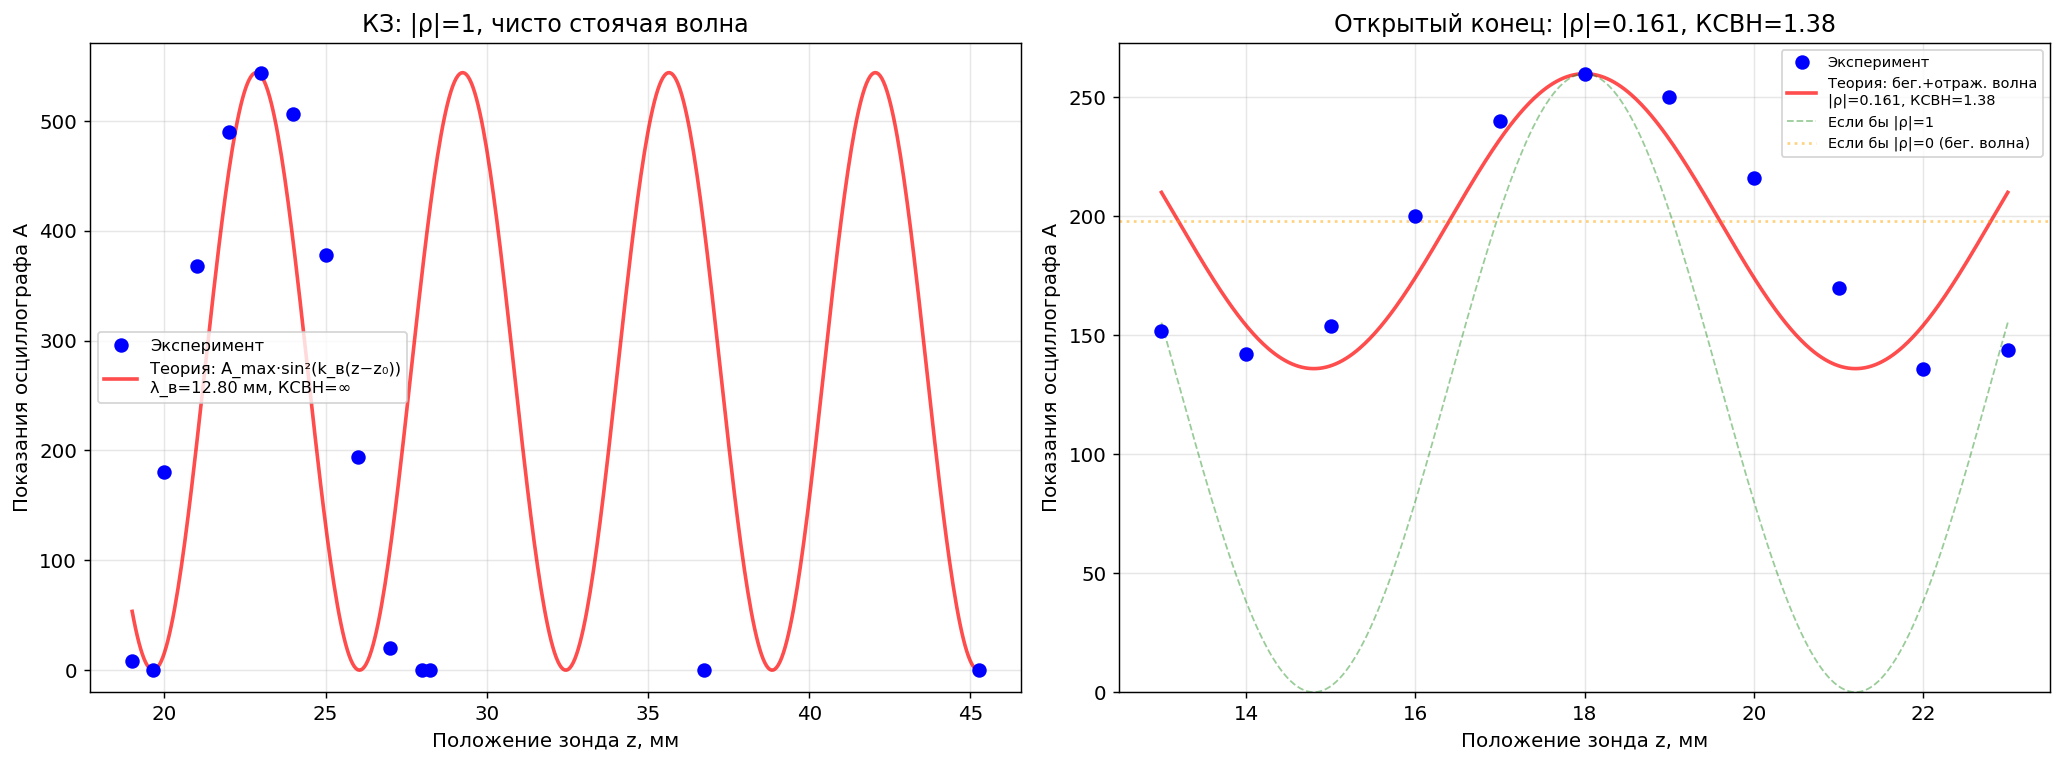

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================
# КЗ: теоретическая стоячая волна
# ==========================
ax = axes[0]
data_sc = experiment["tension_distribution"]["short_circuit"]
pos_sc = np.array(sorted(data_sc.keys()))
amp_sc = np.array([data_sc[p] for p in pos_sc])

# Эксперимент
ax.plot(pos_sc, amp_sc, 'bo', ms=7, zorder=5, label='Эксперимент')

# Теория: КЗ → чисто стоячая волна, |ρ|=1
# A(z) ∝ sin²(k_в · (z - z_КЗ)),  где z_КЗ — позиция КЗ (узел)
# k_в = 2π/λ_в
# Для квадратичного детектора: показания ∝ E² ∝ sin²(...)

# Позиция КЗ — ближайший нуль к концу (максимальная z с A=0)
z_kz = zeros.max()  # последний нуль
k_wg = 2 * np.pi / lam_wg_exp_sc

z_fine = np.linspace(pos_sc.min(), pos_sc.max(), 500)
# A_теор = A_max · sin²(k_в · (z - z_КЗ))
A_theor_sc = A_max_sc * np.sin(k_wg * (z_fine - z_kz))**2

ax.plot(z_fine, A_theor_sc, 'r-', lw=2, alpha=0.7,
        label=f'Теория: A_max·sin²(k_в(z−z₀))\nλ_в={lam_wg_exp_sc:.2f} мм, КСВН=∞')
ax.set_xlabel('Положение зонда z, мм')
ax.set_ylabel('Показания осциллографа A')
ax.set_title('КЗ: |ρ|=1, чисто стоячая волна')
ax.legend(fontsize=9)
ax.set_ylim(bottom=-20)

# ==========================
# Открытый конец: теоретическая стоячая волна
# ==========================
ax = axes[1]
data_op = experiment["tension_distribution"]["open"]
pos_op = np.array(sorted(data_op.keys()))
amp_op = np.array([data_op[p] for p in pos_op])

ax.plot(pos_op, amp_op, 'bo', ms=7, zorder=5, label='Эксперимент')

# Теория: суперпозиция падающей и отражённой волн
# E(z) = E₀ [exp(ik_в z) + ρ exp(-ik_в z)]
# |E(z)|² = E₀² |1 + ρ exp(-2ik_в z)|²
# Для квадратичного детектора: A(z) ∝ |1 + |ρ| exp(-2ik_в(z-z₀))|²
# A(z) = A_ср · [1 + |ρ|² + 2|ρ|cos(2k_в(z-z₀))]
# A_max = A_ср · (1 + |ρ|)²
# A_min = A_ср · (1 - |ρ|)²

# Используем экспериментальный |ρ|
# Находим z₀ из позиции максимума
idx_max_op = np.argmax(amp_op)
z0_op = pos_op[idx_max_op]

# Определим λ_в из данных КЗ (более надёжно)
k_wg_op = 2 * np.pi / lam_wg_exp_sc

z_fine_op = np.linspace(pos_op.min(), pos_op.max(), 500)

# Нормировка: A_ср = A_max / (1+|ρ|)²
A_avg = A_max_op / (1 + rho_op)**2
A_theor_op = A_avg * (1 + rho_op**2 + 2*rho_op*np.cos(2*k_wg_op*(z_fine_op - z0_op)))

ax.plot(z_fine_op, A_theor_op, 'r-', lw=2, alpha=0.7,
        label=f'Теория: бег.+отраж. волна\n|ρ|={rho_op:.3f}, КСВН={vswr_op:.2f}')

# Для сравнения: если бы |ρ|=1 (как КЗ)
A_theor_kz = A_max_op * np.cos(k_wg_op*(z_fine_op - z0_op))**2
ax.plot(z_fine_op, A_theor_kz, 'g--', lw=1, alpha=0.4,
        label='Если бы |ρ|=1')

# Для сравнения: если бы |ρ|=0 (согласованная)
ax.axhline(A_avg * (1 + rho_op**2), color='orange', ls=':', lw=1.5,
           alpha=0.5, label='Если бы |ρ|=0 (бег. волна)')

ax.set_xlabel('Положение зонда z, мм')
ax.set_ylabel('Показания осциллографа A')
ax.set_title(f'Открытый конец: |ρ|={rho_op:.3f}, КСВН={vswr_op:.2f}')
ax.legend(fontsize=8)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

ТЕОРЕТИЧЕСКИЙ КСВН: ДИЭЛЕКТРИЧЕСКАЯ ПЛАСТИНА

Для СИЛЬНО ПОГЛОЩАЮЩЕЙ диэлектрической пластины,
установленной вплотную к открытому концу волновода,
отражение от задней грани подавлено (волна затухает).

Отражение только от передней границы воздух → диэлектрик:

    ρ = (1 − √ε) / (1 + √ε)      (нормальное падение, μ=1)

    КСВН = (1 + |ρ|) / (1 − |ρ|)



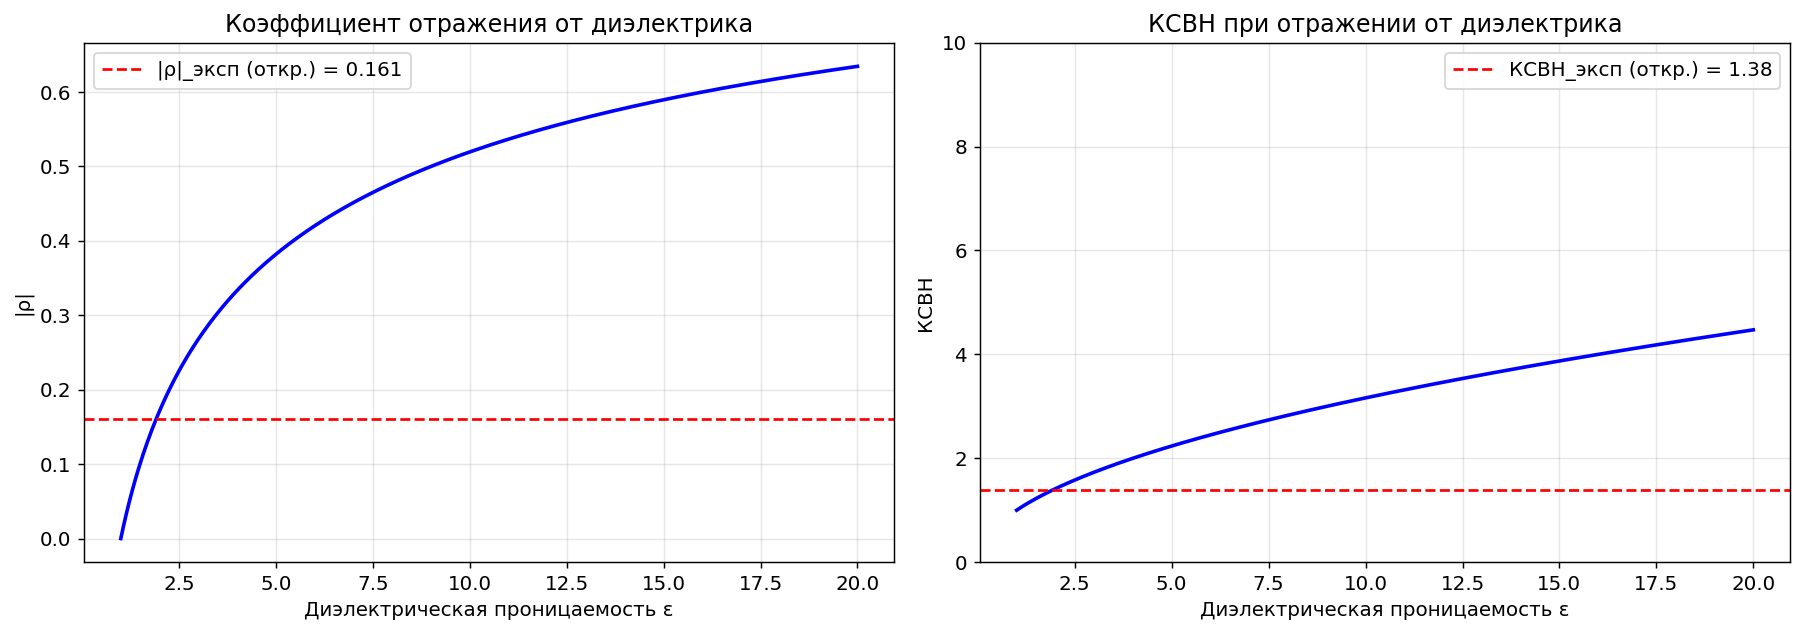

Обратная задача: определение ε из измеренного |ρ|

  |ρ|_эксп (открытый конец) = 0.1606
  √ε = (1+|ρ|)/(1−|ρ|) = 1.3827
  ε = 1.912

Материал                 ε      |ρ|     КСВН
---------------------------------------------
Воздух                 1.0   0.0000    1.000
Тефлон                 2.1   0.1834    1.449
Полиэтилен             2.3   0.2053    1.517
Оргстекло              3.4   0.2967    1.844
Стекло                 5.0   0.3820    2.236
Керамика               9.0   0.5000    3.000
Вода                  80.0   0.7989    8.944


In [45]:
print("=" * 65)
print("ТЕОРЕТИЧЕСКИЙ КСВН: ДИЭЛЕКТРИЧЕСКАЯ ПЛАСТИНА")
print("=" * 65)
print("""
Для СИЛЬНО ПОГЛОЩАЮЩЕЙ диэлектрической пластины,
установленной вплотную к открытому концу волновода,
отражение от задней грани подавлено (волна затухает).

Отражение только от передней границы воздух → диэлектрик:

    ρ = (1 − √ε) / (1 + √ε)      (нормальное падение, μ=1)

    КСВН = (1 + |ρ|) / (1 − |ρ|)
""")

# Построим зависимость КСВН(ε) и |ρ|(ε)
eps_range = np.linspace(1.0, 20.0, 500)
rho_range = np.abs((1 - np.sqrt(eps_range)) / (1 + np.sqrt(eps_range)))
vswr_range = (1 + rho_range) / (1 - rho_range)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(eps_range, rho_range, 'b-', lw=2)
ax1.set_xlabel('Диэлектрическая проницаемость ε')
ax1.set_ylabel('|ρ|')
ax1.set_title('Коэффициент отражения от диэлектрика')
ax1.axhline(rho_op, color='r', ls='--', label=f'|ρ|_эксп (откр.) = {rho_op:.3f}')
ax1.legend()

ax2.plot(eps_range, vswr_range, 'b-', lw=2)
ax2.set_xlabel('Диэлектрическая проницаемость ε')
ax2.set_ylabel('КСВН')
ax2.set_title('КСВН при отражении от диэлектрика')
ax2.set_ylim(0, 10)
ax2.axhline(vswr_op, color='r', ls='--', label=f'КСВН_эксп (откр.) = {vswr_op:.2f}')
ax2.legend()

plt.tight_layout()
plt.show()

# Обратная задача: ε из |ρ|
print("Обратная задача: определение ε из измеренного |ρ|")
print(f"\n  |ρ|_эксп (открытый конец) = {rho_op:.4f}")
sqrt_eps_from_rho = (1 + rho_op) / (1 - rho_op)
eps_from_rho = sqrt_eps_from_rho**2
print(f"  √ε = (1+|ρ|)/(1−|ρ|) = {sqrt_eps_from_rho:.4f}")
print(f"  ε = {eps_from_rho:.3f}")

# Таблица: КСВН для типичных диэлектриков
print(f"\n{'Материал':<20} {'ε':>5} {'|ρ|':>8} {'КСВН':>8}")
print("-" * 45)
materials = {
    "Воздух":        1.0,
    "Тефлон":        2.1,
    "Полиэтилен":    2.3,
    "Оргстекло":     3.4,
    "Стекло":        5.0,
    "Керамика":      9.0,
    "Вода":         80.0,
}
for mat, eps in materials.items():
    rho_m = abs((1 - np.sqrt(eps)) / (1 + np.sqrt(eps)))
    vswr_m = (1 + rho_m) / (1 - rho_m) if rho_m < 1 else np.inf
    vswr_s = f"{vswr_m:.3f}" if vswr_m < 100 else f"{vswr_m:.1f}"
    print(f"{mat:<20} {eps:>5.1f} {rho_m:>8.4f} {vswr_s:>8}")

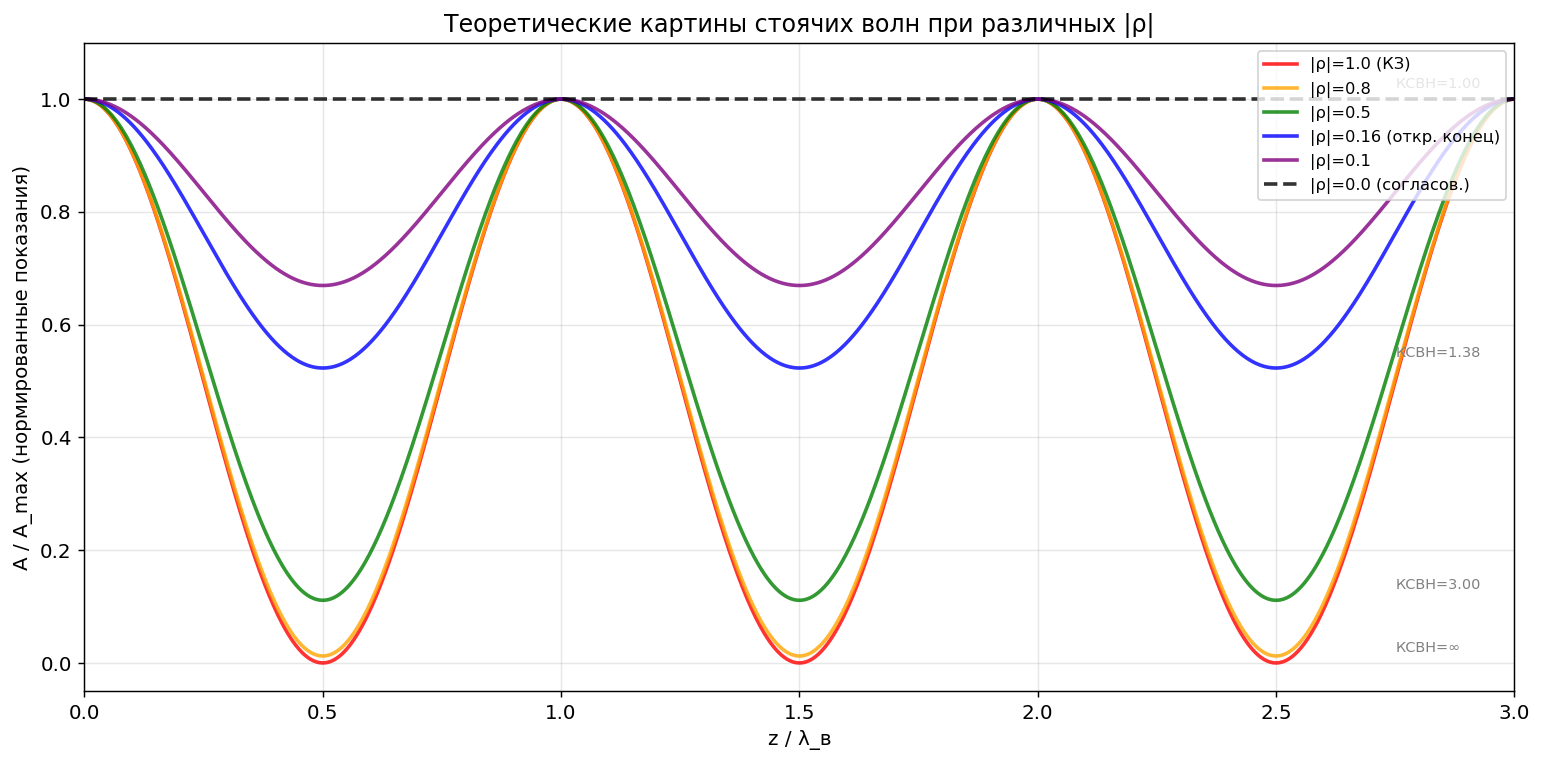

На графике видно:
  • При |ρ|=1 (КЗ): чисто стоячая волна, A_min=0, КСВН=∞
  • При |ρ|=0 (согласов.): чисто бегущая, A=const, КСВН=1
  • Открытый конец (|ρ|=0.16): промежуточный случай


In [46]:
fig, ax = plt.subplots(figsize=(12, 6))

z = np.linspace(0, 3, 1000)  # в единицах λ_в

rho_values = [1.0, 0.8, 0.5, rho_op, 0.1, 0.0]
labels = ['|ρ|=1.0 (КЗ)', '|ρ|=0.8', '|ρ|=0.5',
          f'|ρ|={rho_op:.2f} (откр. конец)', '|ρ|=0.1',
          '|ρ|=0.0 (согласов.)']
colors = ['red', 'orange', 'green', 'blue', 'purple', 'black']
styles = ['-', '-', '-', '-', '-', '--']

for rho_val, label, col, ls in zip(rho_values, labels, colors, styles):
    # A(z) ∝ |1 + ρ·exp(2πi·z)|²
    #      = 1 + ρ² + 2ρ·cos(2π·z)
    A = 1 + rho_val**2 + 2*rho_val*np.cos(2*np.pi*z)
    # Нормировка на максимум
    A_norm = A / A.max()
    ax.plot(z, A_norm, ls, lw=2, color=col, alpha=0.8, label=label)

ax.set_xlabel('z / λ_в')
ax.set_ylabel('A / A_max (нормированные показания)')
ax.set_title('Теоретические картины стоячих волн при различных |ρ|')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 3)
ax.set_ylim(-0.05, 1.1)

# Аннотация КСВН
for rho_val in [1.0, 0.5, rho_op, 0.0]:
    if rho_val < 1:
        vswr_val = (1+rho_val)/(1-rho_val)
        ax.annotate(f'КСВН={vswr_val:.2f}',
                    xy=(2.75, (1+rho_val**2-2*rho_val)/(1+rho_val)**2 + 0.02),
                    fontsize=8, color='gray')
    else:
        ax.annotate('КСВН=∞', xy=(2.75, 0.02), fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print("На графике видно:")
print("  • При |ρ|=1 (КЗ): чисто стоячая волна, A_min=0, КСВН=∞")
print("  • При |ρ|=0 (согласов.): чисто бегущая, A=const, КСВН=1")
print(f"  • Открытый конец (|ρ|={rho_op:.2f}): промежуточный случай")

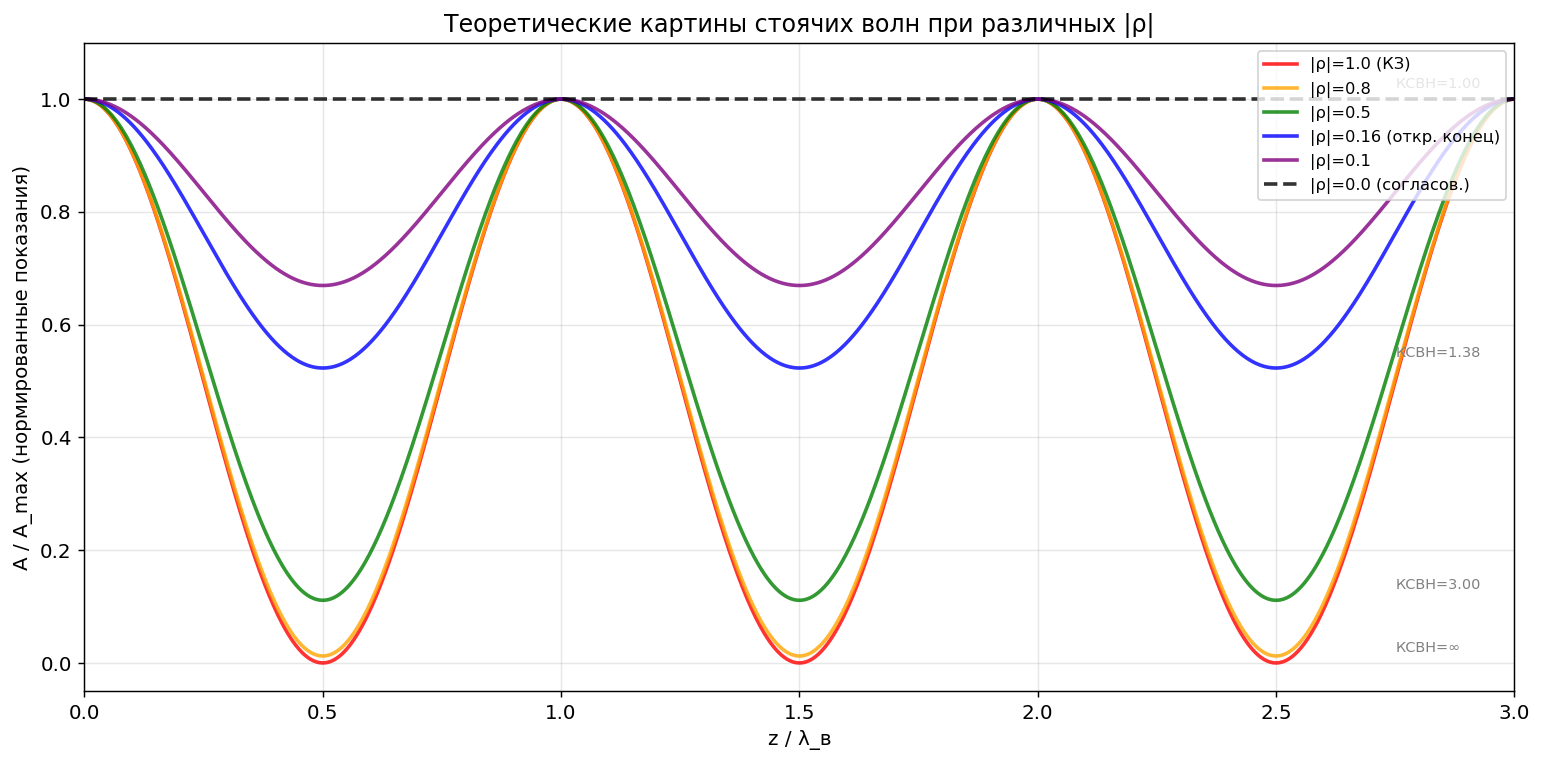

На графике видно:
  • При |ρ|=1 (КЗ): чисто стоячая волна, A_min=0, КСВН=∞
  • При |ρ|=0 (согласов.): чисто бегущая, A=const, КСВН=1
  • Открытый конец (|ρ|=0.16): промежуточный случай


In [47]:
fig, ax = plt.subplots(figsize=(12, 6))

z = np.linspace(0, 3, 1000)  # в единицах λ_в

rho_values = [1.0, 0.8, 0.5, rho_op, 0.1, 0.0]
labels = ['|ρ|=1.0 (КЗ)', '|ρ|=0.8', '|ρ|=0.5',
          f'|ρ|={rho_op:.2f} (откр. конец)', '|ρ|=0.1',
          '|ρ|=0.0 (согласов.)']
colors = ['red', 'orange', 'green', 'blue', 'purple', 'black']
styles = ['-', '-', '-', '-', '-', '--']

for rho_val, label, col, ls in zip(rho_values, labels, colors, styles):
    # A(z) ∝ |1 + ρ·exp(2πi·z)|²
    #      = 1 + ρ² + 2ρ·cos(2π·z)
    A = 1 + rho_val**2 + 2*rho_val*np.cos(2*np.pi*z)
    # Нормировка на максимум
    A_norm = A / A.max()
    ax.plot(z, A_norm, ls, lw=2, color=col, alpha=0.8, label=label)

ax.set_xlabel('z / λ_в')
ax.set_ylabel('A / A_max (нормированные показания)')
ax.set_title('Теоретические картины стоячих волн при различных |ρ|')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 3)
ax.set_ylim(-0.05, 1.1)

# Аннотация КСВН
for rho_val in [1.0, 0.5, rho_op, 0.0]:
    if rho_val < 1:
        vswr_val = (1+rho_val)/(1-rho_val)
        ax.annotate(f'КСВН={vswr_val:.2f}',
                    xy=(2.75, (1+rho_val**2-2*rho_val)/(1+rho_val)**2 + 0.02),
                    fontsize=8, color='gray')
    else:
        ax.annotate('КСВН=∞', xy=(2.75, 0.02), fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print("На графике видно:")
print("  • При |ρ|=1 (КЗ): чисто стоячая волна, A_min=0, КСВН=∞")
print("  • При |ρ|=0 (согласов.): чисто бегущая, A=const, КСВН=1")
print(f"  • Открытый конец (|ρ|={rho_op:.2f}): промежуточный случай")

In [30]:
print("=" * 60)
print("РАСЧЁТ ДИЭЛЕКТРИЧЕСКОЙ ПРОНИЦАЕМОСТИ")
print("(формулы Френеля, нормальное падение, μ = 1)")
print("=" * 60)

print("""
Для нормального падения на границу среда₁ → среда₂:

    ρ = (Z₁ − Z₂) / (Z₁ + Z₂)

где Z = √(μ/ε).  При μ₁ = μ₂ = 1:

    ρ = (n₂ − n₁) / (n₂ + n₁) = (√ε₂ − √ε₁) / (√ε₂ + √ε₁)

Для волновода → диэлектрик (n₁ ≈ 1):

    |ρ| = |√ε − 1| / (√ε + 1)

    ⟹  √ε = (1 + |ρ|) / (1 − |ρ|)   (если ε > 1)
    ⟹  ε = [(1 + |ρ|) / (1 − |ρ|)]²
""")

# Используем данные открытого конца
print(f"Для открытого конца:  |ρ| = {rho_op:.4f}")
sqrt_eps = (1 + rho_op) / (1 - rho_op)
eps_open = sqrt_eps**2
print(f"  √ε = (1 + {rho_op:.4f}) / (1 − {rho_op:.4f}) = {sqrt_eps:.4f}")
print(f"  ε   = {eps_open:.3f}")
print(f"\n  (Это оценка эффективной ε для перехода волновод→воздух)")
print(f"  Для настоящего диэлектрика используйте данные с пластиной")

РАСЧЁТ ДИЭЛЕКТРИЧЕСКОЙ ПРОНИЦАЕМОСТИ
(формулы Френеля, нормальное падение, μ = 1)

Для нормального падения на границу среда₁ → среда₂:

    ρ = (Z₁ − Z₂) / (Z₁ + Z₂)

где Z = √(μ/ε).  При μ₁ = μ₂ = 1:

    ρ = (n₂ − n₁) / (n₂ + n₁) = (√ε₂ − √ε₁) / (√ε₂ + √ε₁)

Для волновода → диэлектрик (n₁ ≈ 1):

    |ρ| = |√ε − 1| / (√ε + 1)

    ⟹  √ε = (1 + |ρ|) / (1 − |ρ|)   (если ε > 1)
    ⟹  ε = [(1 + |ρ|) / (1 − |ρ|)]²

Для открытого конца:  |ρ| = 0.1606
  √ε = (1 + 0.1606) / (1 − 0.1606) = 1.3827
  ε   = 1.912

  (Это оценка эффективной ε для перехода волновод→воздух)
  Для настоящего диэлектрика используйте данные с пластиной


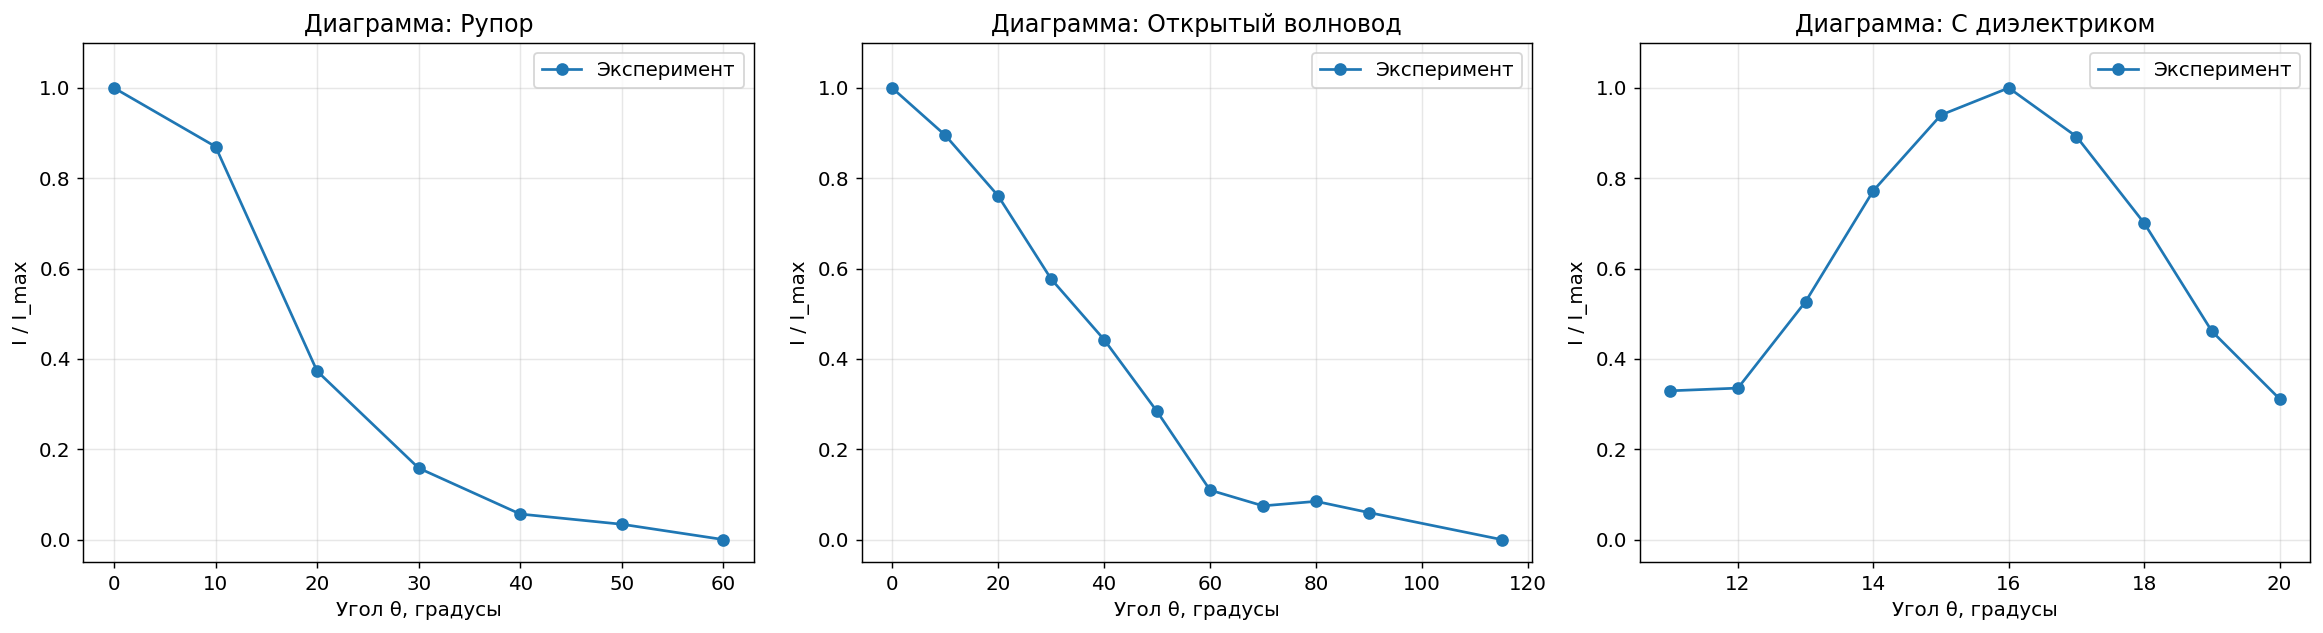

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names_ru = {
    "megaphone": "Рупор",
    "open_waveguide": "Открытый волновод",
    "with_dielectric": "С диэлектриком"
}

for ax, (name, data) in zip(axes, experiment["radiation_pattern"].items()):
    angles = np.array(sorted(data.keys()), dtype=float)
    amps   = np.array([data[a] for a in angles], dtype=float)
    
    # Нормировка на максимум
    I_norm = amps / amps.max()
    
    ax.plot(angles, I_norm, 'o-', ms=6, lw=1.5, label='Эксперимент')
    
    # Теоретическая дифракция: I ∝ sinc²(πD sinθ / λ)
    # Для рупора D ≈ раскрыв, для волновода D ≈ a
    ax.set_xlabel("Угол θ, градусы")
    ax.set_ylabel("I / I_max")
    ax.set_title(f"Диаграмма: {names_ru[name]}")
    ax.legend()
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

ДИАГРАММЫ НАПРАВЛЕННОСТИ — ДЕКАРТОВЫ КООРДИНАТЫ


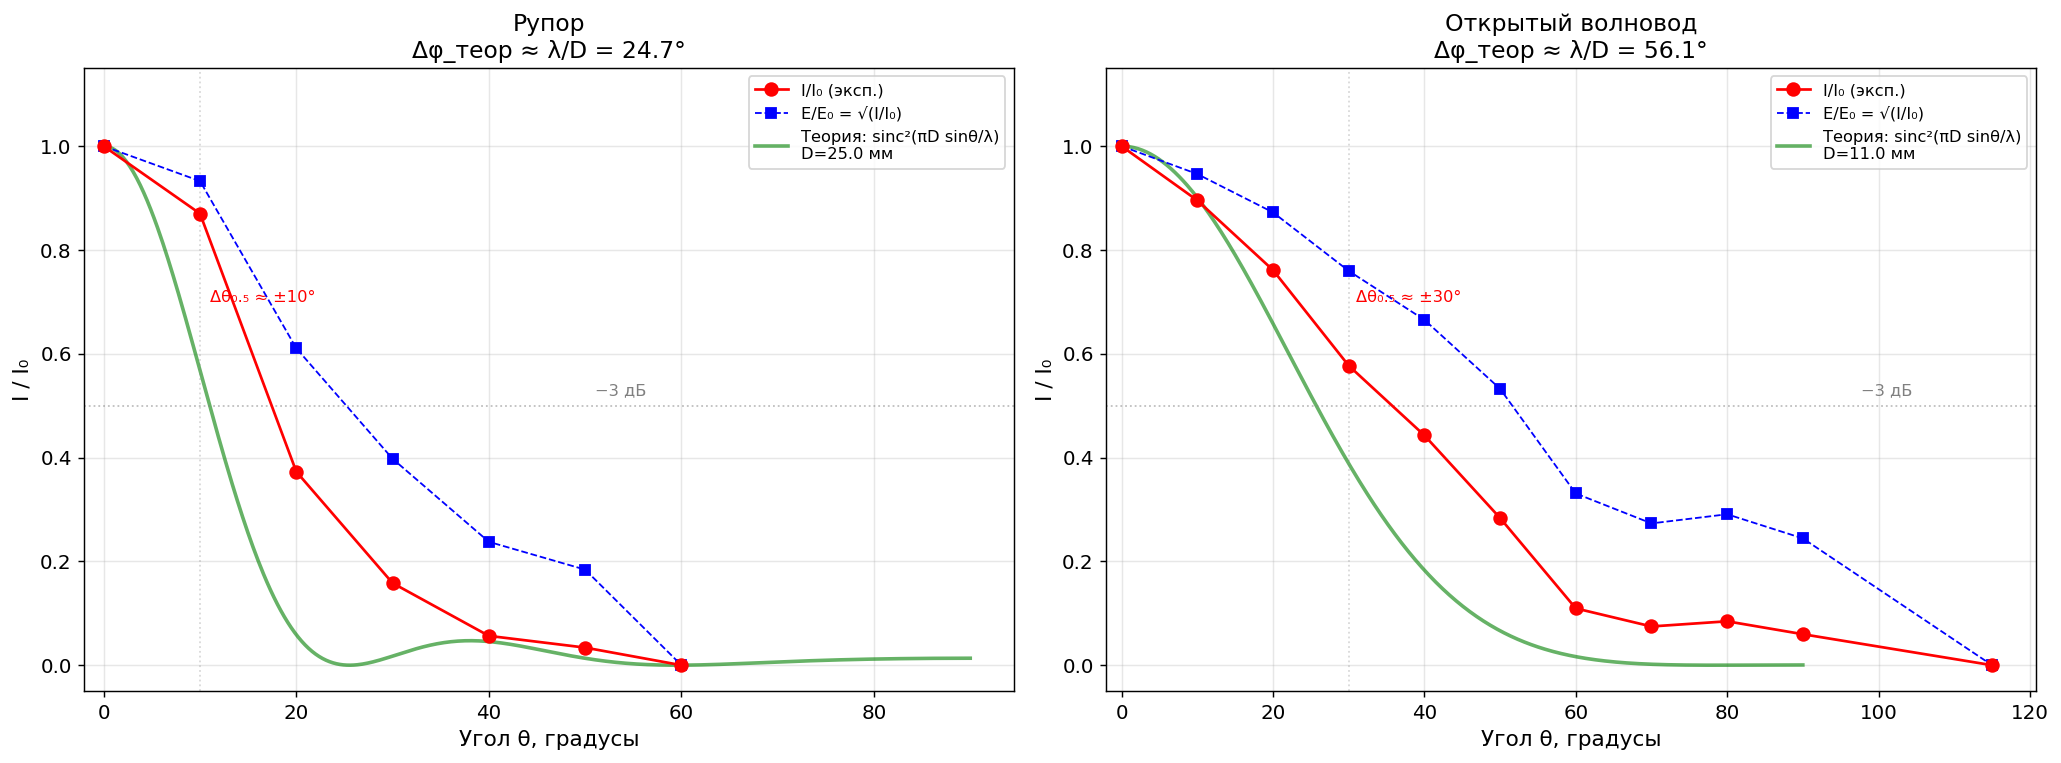


Излучатель                Δθ₀.₅ эксп   Δφ~λ/D теор   D_эфф, мм
--------------------------------------------------------------
Рупор                          ±10°       ±24.7°        25.0
Открытый волновод              ±30°       ±56.1°        11.0

λ₀ = 10.8 мм

Объяснение расхождений:
  • Формула Δφ~λ/D даёт лишь порядок величины
  • Рупор имеет неравномерное распределение поля в раскрыве
  • Открытый волновод: дифракция на конечной стенке + отражения
  • Измерения в ближней зоне завышают ширину диаграммы


In [51]:
print("=" * 60)
print("ДИАГРАММЫ НАПРАВЛЕННОСТИ — ДЕКАРТОВЫ КООРДИНАТЫ")
print("=" * 60)

# Данные
patterns = {
    "Рупор": experiment["radiation_pattern"]["megaphone"],
    "Открытый волновод": experiment["radiation_pattern"]["open_waveguide"],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, data) in zip(axes, patterns.items()):
    angles = np.array(sorted(data.keys()), dtype=float)
    amps   = np.array([data[a] for a in angles], dtype=float)
    
    # Квадратичный детектор: показания ∝ E²
    # Нормированная интенсивность
    I_norm = amps / amps.max()
    
    # Нормированная амплитуда поля
    E_norm = np.sqrt(I_norm)
    
    # --- Эксперимент ---
    ax.plot(angles, I_norm, 'ro-', ms=7, lw=1.5, zorder=5,
            label='I/I₀ (эксп.)')
    ax.plot(angles, E_norm, 'bs--', ms=5, lw=1, zorder=4,
            label='E/E₀ = √(I/I₀)')
    
    # --- Теория: дифракция на прямоугольном отверстии ---
    # I(θ) = I₀ · sinc²(π a sinθ / λ₀) · sinc²(π b sinθ_⊥ / λ₀)
    # В плоскости E (вдоль узкой стенки b): sinc²(π b sinθ / λ₀)
    # В плоскости H (вдоль широкой стенки a): более сложная формула
    # Упрощённо для одномерной щели шириной D:
    #   I(θ)/I₀ = sinc²(π D sinθ / λ₀)
    
    # Для рупора D ≈ раскрыв (больше волновода)
    # Для открытого волновода D ≈ a (широкая стенка)
    
    if name == "Рупор":
        D_eff = 25.0  # мм — примерный раскрыв рупора (подберите)
    else:
        D_eff = 11.0  # мм — широкая стенка волновода
    
    theta_fine = np.linspace(0, 90, 500)
    arg = np.pi * D_eff * np.sin(np.deg2rad(theta_fine)) / lam0_mm
    # sinc(x) = sin(x)/x, но np.sinc(x) = sin(πx)/(πx)
    I_theor = np.sinc(arg / np.pi)**2
    
    ax.plot(theta_fine, I_theor, 'g-', lw=2, alpha=0.6,
            label=f'Теория: sinc²(πD sinθ/λ)\nD={D_eff} мм')
    
    # --- Уровень −3 дБ (половинная мощность) ---
    ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)
    ax.annotate('−3 дБ', xy=(angles.max()*0.85, 0.52),
                fontsize=9, color='gray')
    
    # --- Ширина диаграммы ---
    above_half = angles[I_norm >= 0.5]
    if len(above_half) > 0:
        half_width = above_half.max()
        ax.axvline(half_width, color='gray', ls=':', lw=1, alpha=0.3)
        ax.annotate(f'Δθ₀.₅ ≈ ±{half_width:.0f}°',
                    xy=(half_width + 1, 0.7), fontsize=9, color='red')
    
    # Теоретическая расходимость Δφ ~ λ/D
    dphi_theor = np.rad2deg(lam0_mm / D_eff)
    
    ax.set_xlabel('Угол θ, градусы', fontsize=12)
    ax.set_ylabel('I / I₀', fontsize=12)
    ax.set_title(f'{name}\nΔφ_теор ≈ λ/D = {dphi_theor:.1f}°', fontsize=13)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_xlim(left=-2)
    ax.set_ylim(-0.05, 1.15)

plt.tight_layout()
plt.show()

# --- Числовые результаты ---
print(f"\n{'Излучатель':<22} {'Δθ₀.₅ эксп':>13} {'Δφ~λ/D теор':>13} {'D_эфф, мм':>11}")
print("-" * 62)
for name, data in patterns.items():
    angles = np.array(sorted(data.keys()), dtype=float)
    amps   = np.array([data[a] for a in angles], dtype=float)
    I_norm = amps / amps.max()
    
    above = angles[I_norm >= 0.5]
    hw = above.max() if len(above) > 0 else angles.max()
    
    if name == "Рупор":
        D = 25.0
    else:
        D = 11.0
    dphi = np.rad2deg(lam0_mm / D)
    
    print(f"{name:<22} {'±' + f'{hw:.0f}°':>12} {'±' + f'{dphi:.1f}°':>12} {D:>11.1f}")

print(f"\nλ₀ = {lam0_mm:.1f} мм")
print("\nОбъяснение расхождений:")
print("  • Формула Δφ~λ/D даёт лишь порядок величины")
print("  • Рупор имеет неравномерное распределение поля в раскрыве")
print("  • Открытый волновод: дифракция на конечной стенке + отражения")
print("  • Измерения в ближней зоне завышают ширину диаграммы")

ДИАГРАММЫ НАПРАВЛЕННОСТИ — ПОЛЯРНЫЕ КООРДИНАТЫ


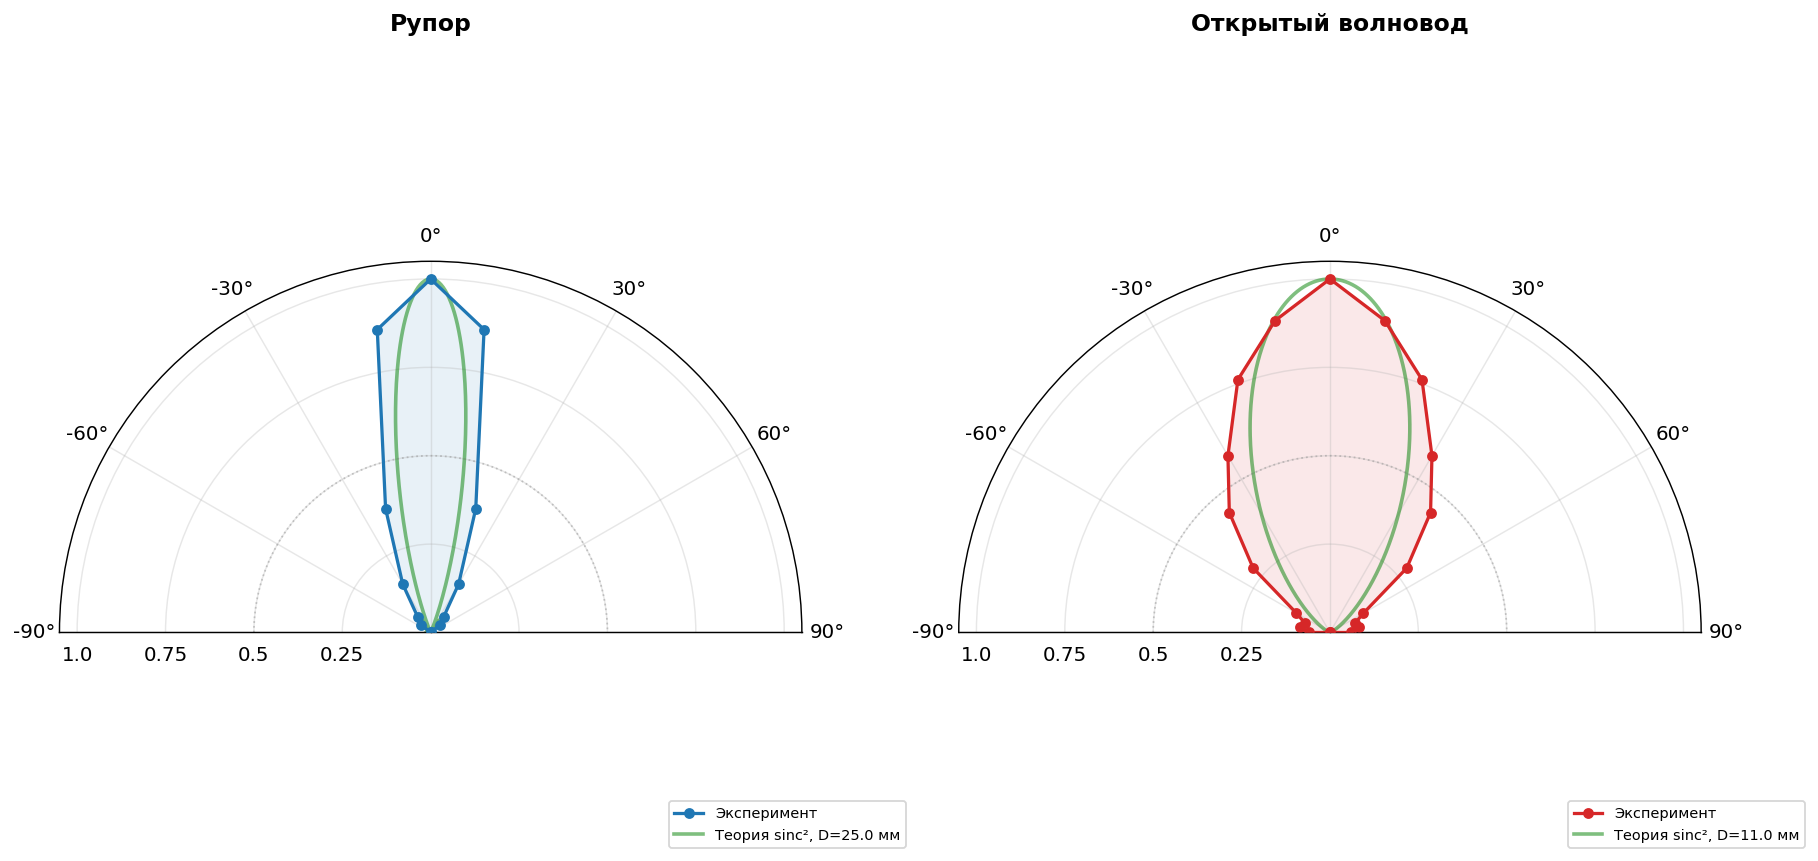

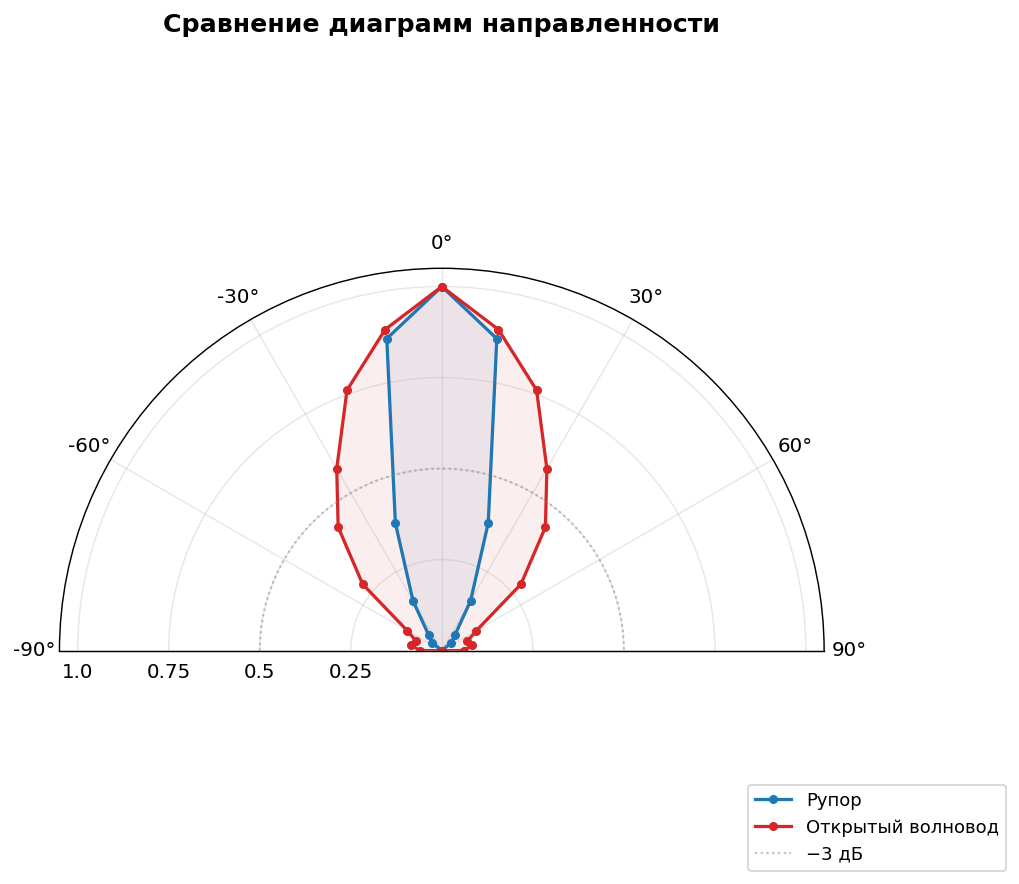


Видно, что рупор имеет значительно более узкую диаграмму
направленности по сравнению с открытым концом волновода,
что обусловлено бо́льшим эффективным размером апертуры D.

  Рупор:              D ≈ 25 мм → Δφ ≈ 24.7°
  Открытый волновод:  D ≈ 11 мм → Δφ ≈ 56.1°


In [52]:
print("=" * 60)
print("ДИАГРАММЫ НАПРАВЛЕННОСТИ — ПОЛЯРНЫЕ КООРДИНАТЫ")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 7),
                         subplot_kw={'projection': 'polar'})

colors_map = {"Рупор": "tab:blue", "Открытый волновод": "tab:red"}
D_map = {"Рупор": 25.0, "Открытый волновод": 11.0}

for ax, (name, data) in zip(axes, patterns.items()):
    angles = np.array(sorted(data.keys()), dtype=float)
    amps   = np.array([data[a] for a in angles], dtype=float)
    I_norm = amps / amps.max()
    
    theta_rad = np.deg2rad(angles)
    col = colors_map[name]
    D_eff = D_map[name]
    
    # --- Зеркальное отражение для полной диаграммы (±θ) ---
    full_theta = np.concatenate([-theta_rad[::-1], theta_rad[1:]])
    full_I     = np.concatenate([I_norm[::-1], I_norm[1:]])
    
    # Эксперимент
    ax.plot(full_theta, full_I, 'o-', ms=5, lw=1.8, color=col,
            zorder=5, label='Эксперимент')
    ax.fill(full_theta, full_I, alpha=0.1, color=col)
    
    # --- Теория: sinc² ---
    theta_fine = np.linspace(-np.pi/2, np.pi/2, 1000)
    arg = np.pi * D_eff * np.sin(theta_fine) / lam0_mm
    I_theor = np.sinc(arg / np.pi)**2
    
    ax.plot(theta_fine, I_theor, '-', lw=2, color='green', alpha=0.5,
            label=f'Теория sinc², D={D_eff} мм')
    
    # --- Уровень −3 дБ ---
    theta_circle = np.linspace(-np.pi/2, np.pi/2, 200)
    ax.plot(theta_circle, 0.5 * np.ones_like(theta_circle),
            ':', color='gray', lw=1, alpha=0.4)
    
    # Настройка полярного графика
    ax.set_thetamin(-90)
    ax.set_thetamax(90)
    ax.set_theta_zero_location('N')  # 0° сверху (вдоль оси излучения)
    ax.set_theta_direction(-1)       # углы по часовой стрелке
    ax.set_rlabel_position(45)
    ax.set_rticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=8)
    ax.set_title(f'{name}', pad=25, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8, 
              bbox_to_anchor=(1.15, -0.05))

plt.tight_layout()
plt.show()

# --- Оба излучателя на одном полярном графике ---
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

for name, data in patterns.items():
    angles = np.array(sorted(data.keys()), dtype=float)
    amps   = np.array([data[a] for a in angles], dtype=float)
    I_norm = amps / amps.max()
    
    theta_rad = np.deg2rad(angles)
    col = colors_map[name]
    
    full_theta = np.concatenate([-theta_rad[::-1], theta_rad[1:]])
    full_I     = np.concatenate([I_norm[::-1], I_norm[1:]])
    
    ax.plot(full_theta, full_I, 'o-', ms=4, lw=1.8, color=col,
            label=name)
    ax.fill(full_theta, full_I, alpha=0.08, color=col)

# Уровень −3 дБ
theta_circle = np.linspace(-np.pi/2, np.pi/2, 200)
ax.plot(theta_circle, 0.5*np.ones_like(theta_circle),
        ':', color='gray', lw=1.2, alpha=0.5, label='−3 дБ')

ax.set_thetamin(-90)
ax.set_thetamax(90)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rlabel_position(45)
ax.set_rticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=9)
ax.set_title('Сравнение диаграмм направленности', pad=25,
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, bbox_to_anchor=(1.25, -0.05))

plt.tight_layout()
plt.show()

print("\nВидно, что рупор имеет значительно более узкую диаграмму")
print("направленности по сравнению с открытым концом волновода,")
print("что обусловлено бо́льшим эффективным размером апертуры D.")
print(f"\n  Рупор:              D ≈ {D_map['Рупор']:.0f} мм → Δφ ≈ {np.rad2deg(lam0_mm/D_map['Рупор']):.1f}°")
print(f"  Открытый волновод:  D ≈ {D_map['Открытый волновод']:.0f} мм → Δφ ≈ {np.rad2deg(lam0_mm/D_map['Открытый волновод']):.1f}°")

In [32]:
print("=" * 60)
print("СРАВНЕНИЕ С ДИФРАКЦИОННОЙ РАСХОДИМОСТЬЮ  Δφ ~ λ/D")
print("=" * 60)

# Оценка ширины диаграммы по уровню 0.5 (половинная мощность)
for name, data in experiment["radiation_pattern"].items():
    angles = np.array(sorted(data.keys()), dtype=float)
    amps   = np.array([data[a] for a in angles], dtype=float)
    I_norm = amps / amps.max()
    
    # Ширина по половинной мощности (−3 дБ)
    half = 0.5
    above = angles[I_norm >= half]
    if len(above) > 0:
        half_width = above.max()
    else:
        half_width = angles.max()
    
    print(f"\n{names_ru[name]}:")
    print(f"  Ширина диаграммы по уровню 0.5:  Δφ_exp ≈ ±{half_width:.0f}°"
          f"  (полная ≈ {2*half_width:.0f}°)")

print(f"\n{'='*60}")
print("Теоретическая дифракционная расходимость Δφ ~ λ/D:")
print(f"  λ₀ = {lam0_mm:.1f} мм\n")

for wg_name, (a, b) in waveguides.items():
    dphi_a = np.rad2deg(lam0_mm / a)
    dphi_b = np.rad2deg(lam0_mm / b)
    print(f"  Волновод {wg_name} мм:")
    print(f"    По широкой стенке (a={a} мм):  Δφ ≈ {dphi_a:.1f}°")
    print(f"    По узкой стенке  (b={b} мм):  Δφ ≈ {dphi_b:.1f}°")

print(f"\n{'='*60}")
print("Минимальное расстояние для дальней зоны: R > 2D²/λ₀")
for wg_name, (a, b) in waveguides.items():
    D = max(a, b)
    R_min = 2 * D**2 / lam0_mm
    print(f"  Волновод {wg_name}: D={D} мм → R_min = {R_min:.1f} мм"
          f" = {R_min/10:.1f} см")

СРАВНЕНИЕ С ДИФРАКЦИОННОЙ РАСХОДИМОСТЬЮ  Δφ ~ λ/D

Рупор:
  Ширина диаграммы по уровню 0.5:  Δφ_exp ≈ ±10°  (полная ≈ 20°)

Открытый волновод:
  Ширина диаграммы по уровню 0.5:  Δφ_exp ≈ ±30°  (полная ≈ 60°)

С диэлектриком:
  Ширина диаграммы по уровню 0.5:  Δφ_exp ≈ ±18°  (полная ≈ 36°)

Теоретическая дифракционная расходимость Δφ ~ λ/D:
  λ₀ = 10.0 мм

  Волновод 7.2×3.4 мм:
    По широкой стенке (a=7.2 мм):  Δφ ≈ 79.6°
    По узкой стенке  (b=3.4 мм):  Δφ ≈ 168.5°
  Волновод 11×5.5 мм:
    По широкой стенке (a=11.0 мм):  Δφ ≈ 52.1°
    По узкой стенке  (b=5.5 мм):  Δφ ≈ 104.2°

Минимальное расстояние для дальней зоны: R > 2D²/λ₀
  Волновод 7.2×3.4: D=7.2 мм → R_min = 10.4 мм = 1.0 см
  Волновод 11×5.5: D=11.0 мм → R_min = 24.2 мм = 2.4 см


ПОЛЯРИЗАЦИЯ — ЗАКОН МАЛЮСА

Фит: A = I₀·cos²(θ − θ₀) + A_bg
  I₀  = 529.3 ± 14.2
  θ₀  = 90.2° ± 0.8°
  A_bg = 22.5 ± 8.5
  R²  = 0.98861


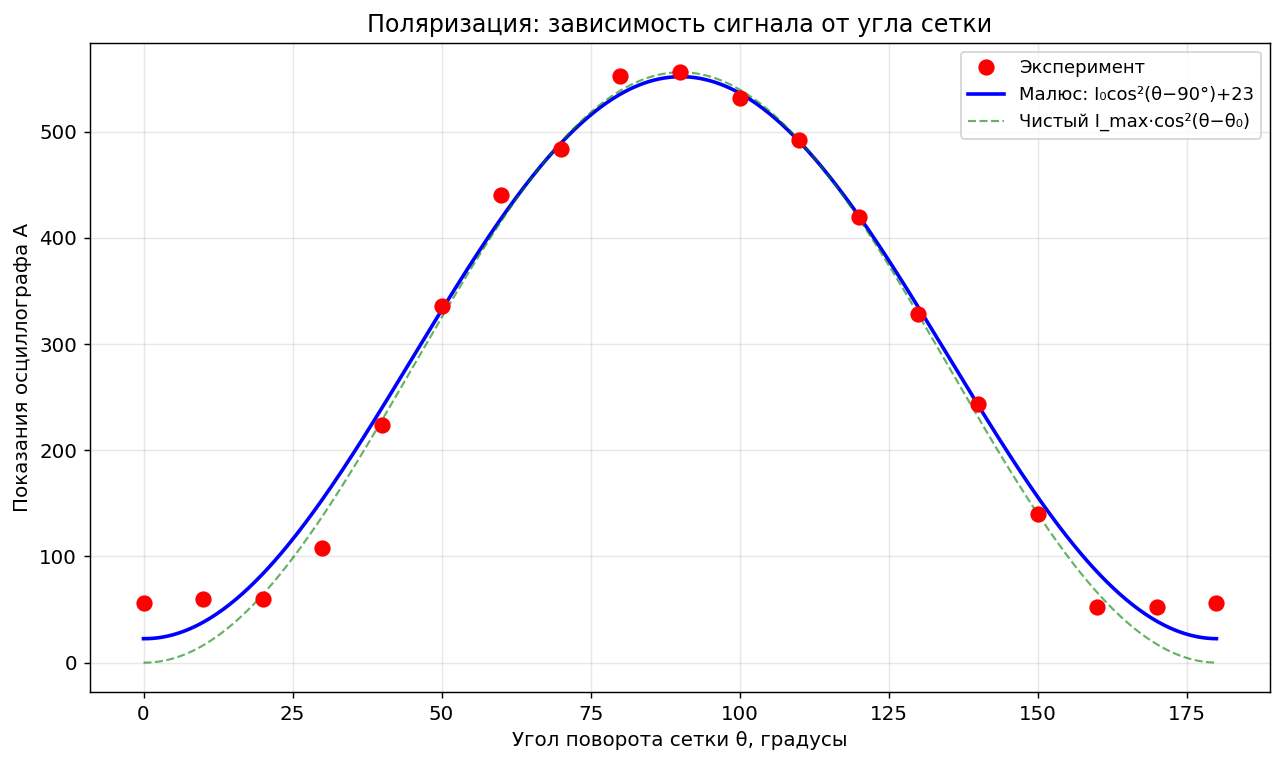


Максимум при θ₀ ≈ 90° — сетка пропускает компоненту E, перпендикулярную проволокам.
Минимумы при 0° и 180° — проволоки параллельны вектору E волновода.


In [33]:
print("=" * 60)
print("ПОЛЯРИЗАЦИЯ — ЗАКОН МАЛЮСА")
print("=" * 60)

data_pol = experiment["polarization"]["gauze"]
angles_pol = np.array(sorted(data_pol.keys()), dtype=float)
amp_pol    = np.array([data_pol[a] for a in angles_pol], dtype=float)
theta_pol  = np.deg2rad(angles_pol)

# Закон Малюса (квадратичный детектор): A ∝ E² ∝ cos²(θ − θ₀)
# Фит: A = I₀ cos²(θ − θ₀) + A_bg

def malus(theta, I0, theta0, A_bg):
    return I0 * np.cos(theta - theta0)**2 + A_bg

popt, pcov = curve_fit(malus, theta_pol, amp_pol,
                       p0=[550, np.pi/2, 50])
I0_fit, th0_fit, Abg_fit = popt
perr = np.sqrt(np.diag(pcov))

print(f"\nФит: A = I₀·cos²(θ − θ₀) + A_bg")
print(f"  I₀  = {I0_fit:.1f} ± {perr[0]:.1f}")
print(f"  θ₀  = {np.rad2deg(th0_fit):.1f}° ± {np.rad2deg(perr[1]):.1f}°")
print(f"  A_bg = {Abg_fit:.1f} ± {perr[2]:.1f}")

# R²
res = amp_pol - malus(theta_pol, *popt)
R2 = 1 - np.sum(res**2) / np.sum((amp_pol - amp_pol.mean())**2)
print(f"  R²  = {R2:.5f}")

# --- График ---
theta_fine = np.linspace(0, np.pi, 500)
A_fit = malus(theta_fine, *popt)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(angles_pol, amp_pol, 'ro', ms=8, zorder=5, label='Эксперимент')
ax.plot(np.rad2deg(theta_fine), A_fit, 'b-', lw=2,
        label=f'Малюс: I₀cos²(θ−{np.rad2deg(th0_fit):.0f}°)+{Abg_fit:.0f}')

# Чистый cos² для сравнения
A_pure = amp_pol.max() * np.cos(theta_fine - th0_fit)**2
ax.plot(np.rad2deg(theta_fine), A_pure, 'g--', lw=1.2, alpha=0.6,
        label='Чистый I_max·cos²(θ−θ₀)')

ax.set_xlabel("Угол поворота сетки θ, градусы")
ax.set_ylabel("Показания осциллографа A")
ax.set_title("Поляризация: зависимость сигнала от угла сетки")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nМаксимум при θ₀ ≈ {np.rad2deg(th0_fit):.0f}° — сетка пропускает "
      f"компоненту E, перпендикулярную проволокам.")
print("Минимумы при 0° и 180° — проволоки параллельны вектору E волновода.")

ПОЛЯРИЗАЦИЯ — ДЕКАРТОВЫ КООРДИНАТЫ

Фит: A = I₀·cos²(θ − θ₀) + A_bg
  I₀   = 529.3 ± 14.2
  θ₀   = 90.2° ± 0.8°
  A_bg = 22.5 ± 8.5
  R²   = 0.98861


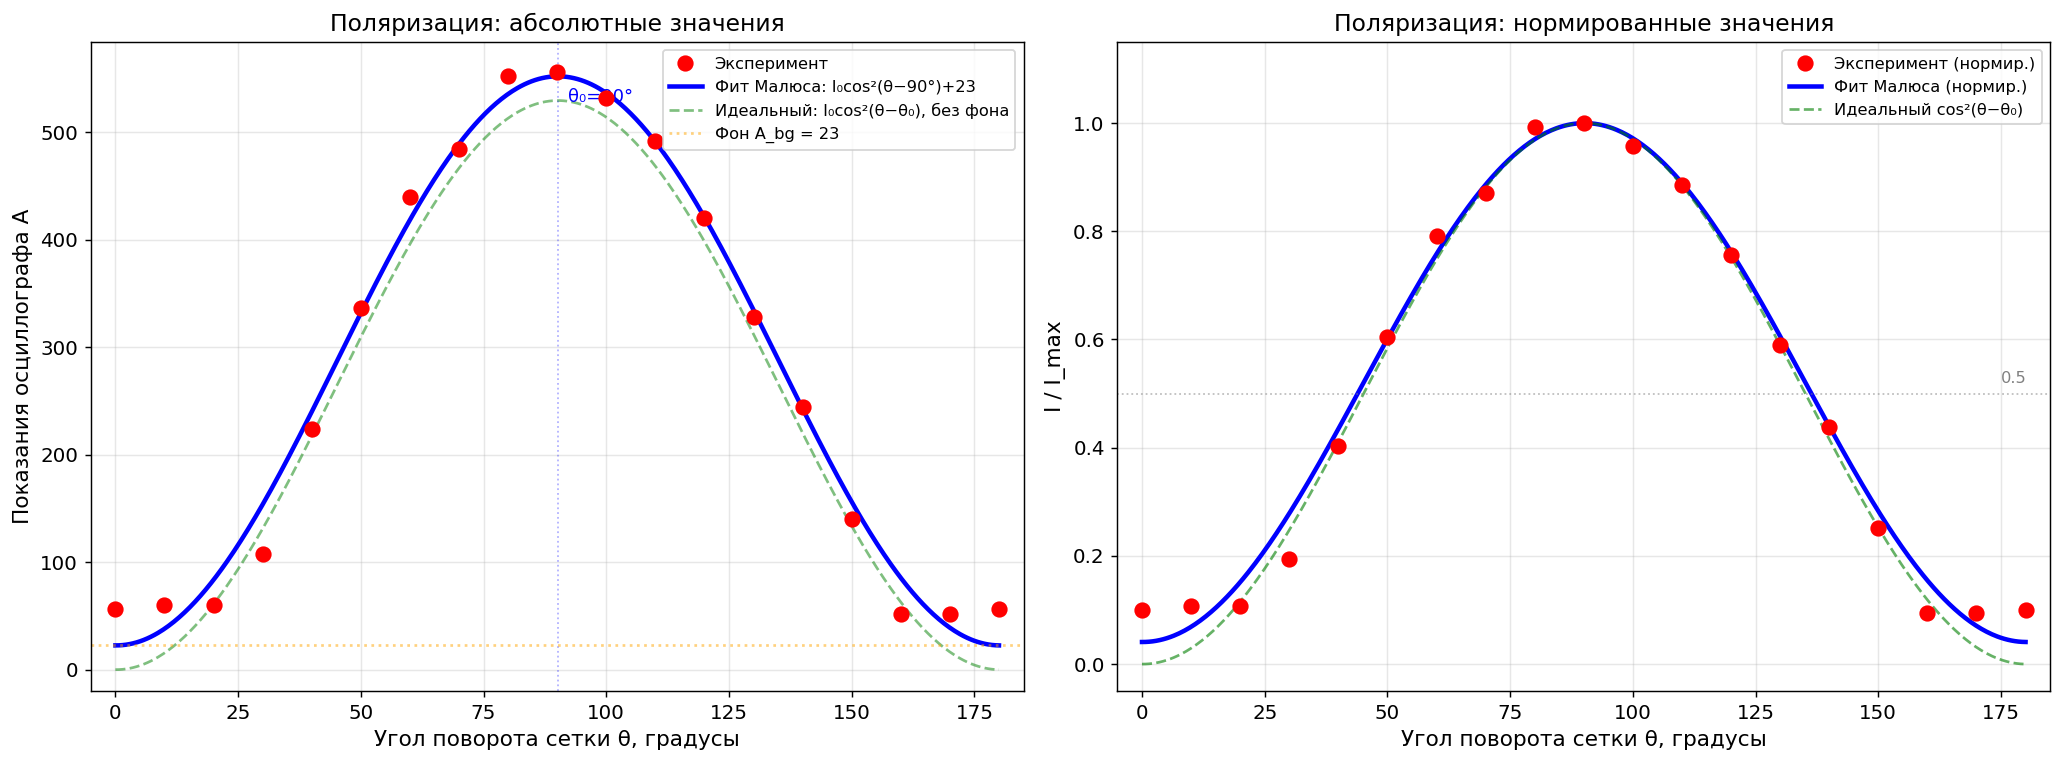


--- Сравнение эксперимента с законом Малюса ---

  θ, °   A_эксп   A_теор        Δ  Δ/A_max,%
--------------------------------------------
     0       56     22.5     33.5        6.0
    10       60     38.0     22.0        4.0
    20       60     83.6    -23.6       -4.2
    30      108    153.7    -45.7       -8.2
    40      224    239.9    -15.9       -2.9
    50      336    331.8      4.2        0.8
    60      440    418.3     21.7        3.9
    70      484    489.0     -5.0       -0.9
    80      552    535.4     16.6        3.0
    90      556    551.8      4.2        0.7
   100      532    536.4     -4.4       -0.8
   110      492    490.8      1.2        0.2
   120      420    420.7     -0.7       -0.1
   130      328    334.5     -6.5       -1.2
   140      244    242.6      1.4        0.2
   150      140    156.1    -16.1       -2.9
   160       52     85.4    -33.4       -6.0
   170       52     39.0     13.0        2.3
   180       56     22.5     33.5        6.0

Сред

In [53]:
print("=" * 60)
print("ПОЛЯРИЗАЦИЯ — ДЕКАРТОВЫ КООРДИНАТЫ")
print("=" * 60)

data_pol = experiment["polarization"]["gauze"]
angles_pol = np.array(sorted(data_pol.keys()), dtype=float)
amp_pol    = np.array([data_pol[a] for a in angles_pol], dtype=float)
theta_pol  = np.deg2rad(angles_pol)

# === Фит закона Малюса ===
# Квадратичный детектор: A ∝ E² ∝ cos²(θ − θ₀)
# Модель: A = I₀·cos²(θ − θ₀) + A_bg

def malus(theta, I0, theta0, A_bg):
    return I0 * np.cos(theta - theta0)**2 + A_bg

popt, pcov = curve_fit(malus, theta_pol, amp_pol,
                       p0=[550, np.pi/2, 50])
I0_fit, th0_fit, Abg_fit = popt
perr = np.sqrt(np.diag(pcov))

# R²
res = amp_pol - malus(theta_pol, *popt)
R2 = 1 - np.sum(res**2) / np.sum((amp_pol - amp_pol.mean())**2)

print(f"\nФит: A = I₀·cos²(θ − θ₀) + A_bg")
print(f"  I₀   = {I0_fit:.1f} ± {perr[0]:.1f}")
print(f"  θ₀   = {np.rad2deg(th0_fit):.1f}° ± {np.rad2deg(perr[1]):.1f}°")
print(f"  A_bg = {Abg_fit:.1f} ± {perr[2]:.1f}")
print(f"  R²   = {R2:.5f}")

# === Теоретические кривые ===
theta_fine = np.linspace(0, np.pi, 500)
A_fit_curve = malus(theta_fine, *popt)

# Чистый закон Малюса (без фона)
A_pure = amp_pol.max() * np.cos(theta_fine - th0_fit)**2

# Идеальный cos² с минимумом = 0
A_ideal = I0_fit * np.cos(theta_fine - th0_fit)**2

# === График ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Левый: абсолютные значения ---
ax1.plot(angles_pol, amp_pol, 'ro', ms=8, zorder=5,
         label='Эксперимент')
ax1.plot(np.rad2deg(theta_fine), A_fit_curve, 'b-', lw=2.5,
         label=f'Фит Малюса: I₀cos²(θ−{np.rad2deg(th0_fit):.0f}°)+{Abg_fit:.0f}')
ax1.plot(np.rad2deg(theta_fine), A_ideal, 'g--', lw=1.5, alpha=0.5,
         label=f'Идеальный: I₀cos²(θ−θ₀), без фона')

# Отметим максимум и минимумы
ax1.axvline(np.rad2deg(th0_fit), color='blue', ls=':', lw=1, alpha=0.3)
ax1.annotate(f'θ₀={np.rad2deg(th0_fit):.0f}°',
             xy=(np.rad2deg(th0_fit)+2, amp_pol.max()*0.95),
             fontsize=10, color='blue')

# Уровень фона
ax1.axhline(Abg_fit, color='orange', ls=':', lw=1.5, alpha=0.5,
            label=f'Фон A_bg = {Abg_fit:.0f}')

ax1.set_xlabel('Угол поворота сетки θ, градусы', fontsize=12)
ax1.set_ylabel('Показания осциллографа A', fontsize=12)
ax1.set_title('Поляризация: абсолютные значения', fontsize=13)
ax1.legend(fontsize=9)
ax1.set_xlim(-5, 185)
ax1.set_ylim(bottom=-20)

# --- Правый: нормированные значения ---
I_norm_exp = amp_pol / amp_pol.max()
I_norm_fit = A_fit_curve / A_fit_curve.max()
I_norm_ideal = np.cos(theta_fine - th0_fit)**2

ax2.plot(angles_pol, I_norm_exp, 'ro', ms=8, zorder=5,
         label='Эксперимент (нормир.)')
ax2.plot(np.rad2deg(theta_fine), I_norm_fit, 'b-', lw=2.5,
         label='Фит Малюса (нормир.)')
ax2.plot(np.rad2deg(theta_fine), I_norm_ideal, 'g--', lw=1.5, alpha=0.6,
         label='Идеальный cos²(θ−θ₀)')

# Уровень 0.5
ax2.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)
ax2.annotate('0.5', xy=(175, 0.52), fontsize=9, color='gray')

ax2.set_xlabel('Угол поворота сетки θ, градусы', fontsize=12)
ax2.set_ylabel('I / I_max', fontsize=12)
ax2.set_title('Поляризация: нормированные значения', fontsize=13)
ax2.legend(fontsize=9)
ax2.set_xlim(-5, 185)
ax2.set_ylim(-0.05, 1.15)

plt.tight_layout()
plt.show()

# === Числовой анализ ===
print("\n--- Сравнение эксперимента с законом Малюса ---")
print(f"\n{'θ, °':>6} {'A_эксп':>8} {'A_теор':>8} {'Δ':>8} {'Δ/A_max,%':>10}")
print("-" * 44)
for ang, a_exp in zip(angles_pol, amp_pol):
    a_th = malus(np.deg2rad(ang), *popt)
    delta = a_exp - a_th
    delta_pct = delta / amp_pol.max() * 100
    print(f"{ang:>6.0f} {a_exp:>8.0f} {a_th:>8.1f} {delta:>8.1f} {delta_pct:>10.1f}")

print(f"\nСреднеквадр. отклонение: σ = {np.std(res):.1f}")
print(f"Относительное:  σ/A_max = {np.std(res)/amp_pol.max()*100:.1f}%")

print(f"\nФизический смысл:")
print(f"  Максимум при θ₀ ≈ {np.rad2deg(th0_fit):.0f}°: проволоки сетки ⊥ вектору E")
print(f"  Минимум при θ ≈ 0°, 180°: проволоки ∥ вектору E → экранирование")
print(f"  Фон A_bg ≈ {Abg_fit:.0f}: рассеяние, переотражения, утечка")

ПОЛЯРИЗАЦИЯ — ПОЛЯРНЫЕ КООРДИНАТЫ


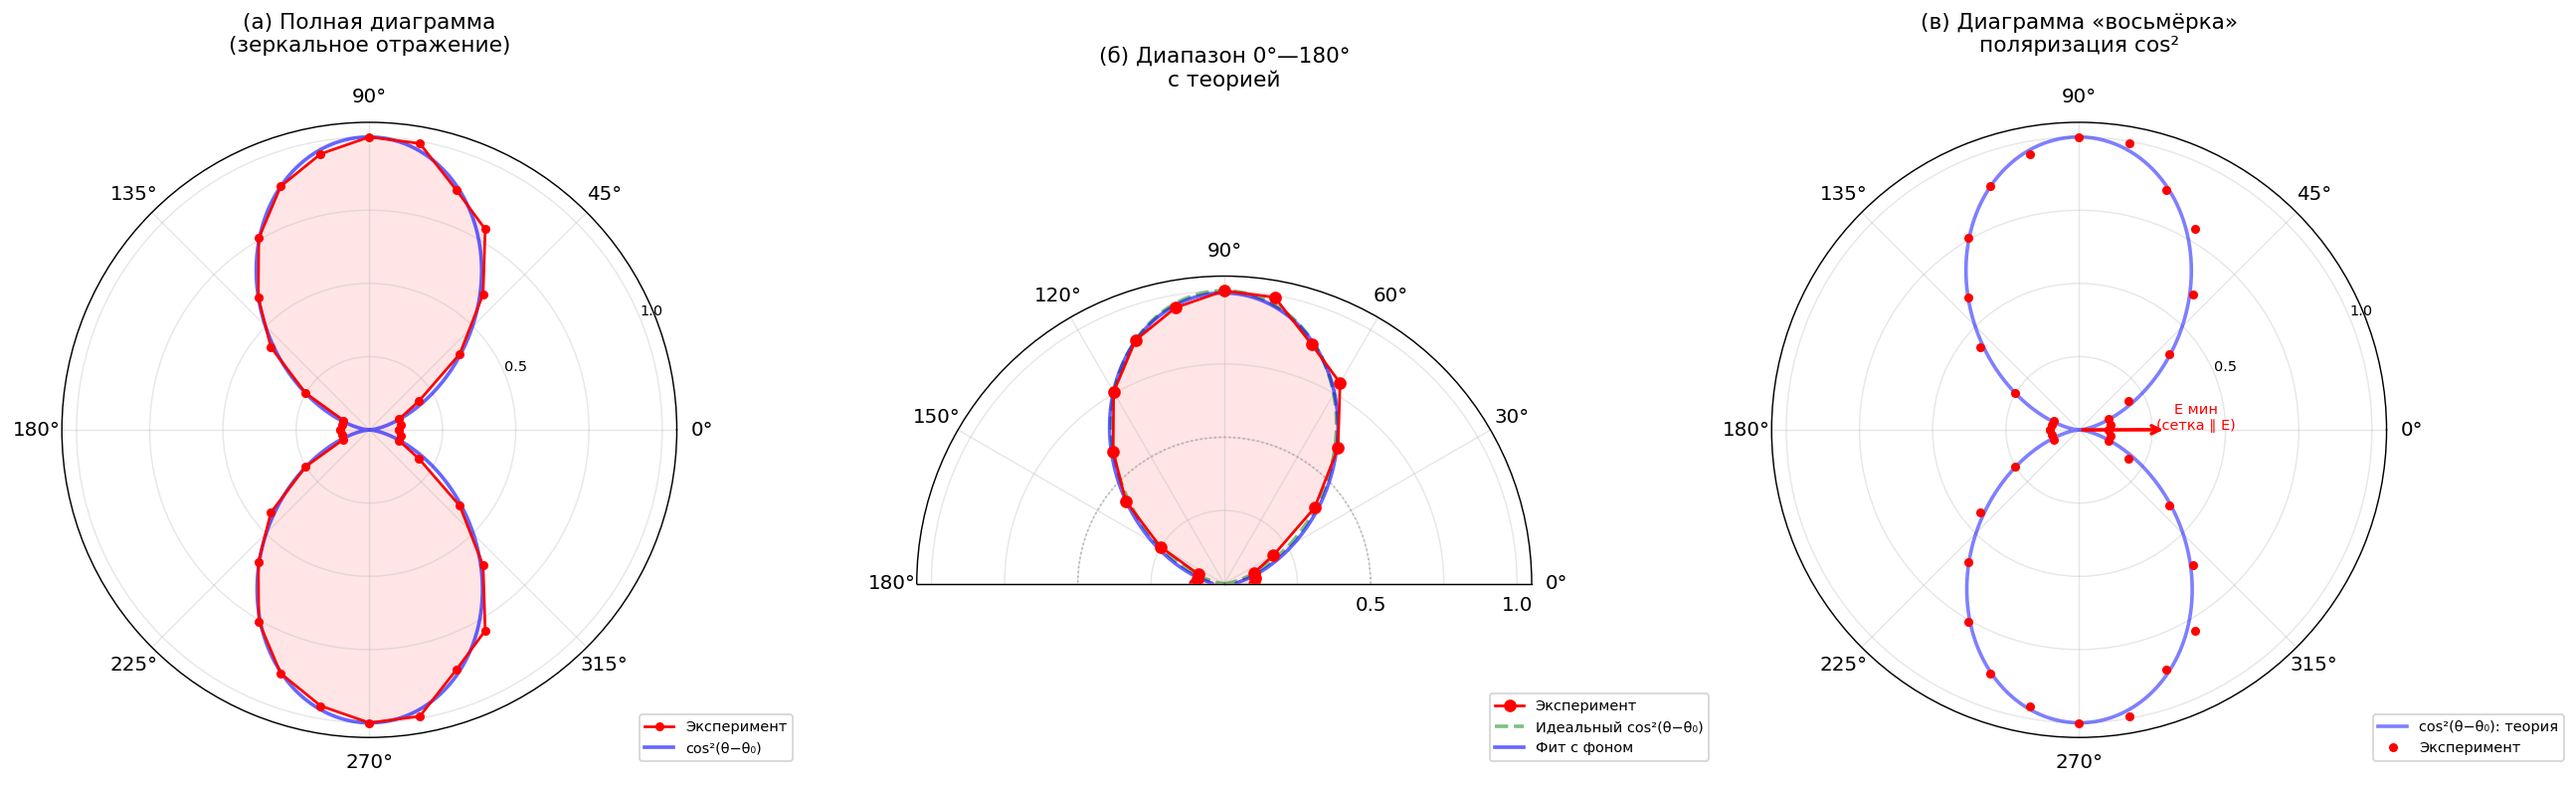

In [56]:
print("=" * 60)
print("ПОЛЯРИЗАЦИЯ — ПОЛЯРНЫЕ КООРДИНАТЫ")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(20, 7),
                         subplot_kw={'projection': 'polar'})

# =========================================================
# (а) Полная диаграмма 0°—360° (зеркальное отражение)
# =========================================================
ax = axes[0]

# Экспериментальные данные: 0°..180°
# Зеркально отражаем для 180°..360°
theta_exp = np.deg2rad(angles_pol)
I_exp_norm = amp_pol / amp_pol.max()

# Полный круг: 0..180 + зеркально 180..360
theta_full = np.concatenate([theta_exp, 2*np.pi - theta_exp[::-1]])
I_full     = np.concatenate([I_exp_norm, I_exp_norm[::-1]])

ax.plot(theta_full, I_full, 'ro-', ms=4, lw=1.5, zorder=5,
        label='Эксперимент')
ax.fill(theta_full, I_full, alpha=0.1, color='red')

# Теория: cos²(θ − θ₀) — полный круг
theta_fine_full = np.linspace(0, 2*np.pi, 1000)
I_malus_full = np.cos(theta_fine_full - th0_fit)**2

ax.plot(theta_fine_full, I_malus_full, 'b-', lw=2, alpha=0.6,
        label='cos²(θ−θ₀)')

ax.set_title('(а) Полная диаграмма\n(зеркальное отражение)',
             pad=20, fontsize=12)
ax.legend(loc='lower right', fontsize=8, bbox_to_anchor=(1.2, -0.05))
ax.set_rticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['', '0.5', '', '1.0'], fontsize=8)

# =========================================================
# (б) Только измеренный диапазон 0°—180°
# =========================================================
ax = axes[1]

ax.plot(theta_exp, I_exp_norm, 'ro-', ms=6, lw=1.5, zorder=5,
        label='Эксперимент')
ax.fill(theta_exp, I_exp_norm, alpha=0.1, color='red')

# Теория
theta_fine_half = np.linspace(0, np.pi, 500)
I_malus_half = np.cos(theta_fine_half - th0_fit)**2
I_malus_fit_half = malus(theta_fine_half, *popt) / amp_pol.max()

ax.plot(theta_fine_half, I_malus_half, 'g--', lw=2, alpha=0.5,
        label='Идеальный cos²(θ−θ₀)')
ax.plot(theta_fine_half, I_malus_fit_half, 'b-', lw=2, alpha=0.6,
        label='Фит с фоном')

# Уровень 0.5
theta_circle = np.linspace(0, np.pi, 200)
ax.plot(theta_circle, 0.5*np.ones_like(theta_circle),
        ':', color='gray', lw=1, alpha=0.5)

ax.set_thetamin(0)
ax.set_thetamax(180)
ax.set_title('(б) Диапазон 0°—180°\nс теорией',
             pad=20, fontsize=12)
ax.legend(loc='lower right', fontsize=8, bbox_to_anchor=(1.3, -0.05))
ax.set_rticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['', '0.5', '', '1.0'], fontsize=8)

# =========================================================
# (в) Диаграмма «восьмёрка» — типичная для cos²
# =========================================================
ax = axes[2]

# cos²(θ) в полярных координатах даёт «восьмёрку» (два лепестка)
# Рисуем в осях, повёрнутых на θ₀

theta_eight = np.linspace(0, 2*np.pi, 1000)
r_eight = np.abs(np.cos(theta_eight - th0_fit))  # |cos| → «восьмёрка»

ax.plot(theta_eight, r_eight**2, 'b-', lw=2, alpha=0.5,
        label='cos²(θ−θ₀): теория')

# Экспериментальные точки (полный круг)
ax.plot(theta_full, I_full, 'ro', ms=4, zorder=5,
        label='Эксперимент')

# Отметим направление E волновода
ax.annotate('', xy=(th0_fit, 1.15), xytext=(th0_fit, 0),
            arrowprops=dict(arrowstyle='->', color='darkblue', lw=2))
ax.annotate('E макс\n(сетка ⊥ E)', xy=(th0_fit, 1.2),
            ha='center', fontsize=8, color='darkblue')

ax.annotate('', xy=(th0_fit - np.pi/2, 0.3),
            xytext=(th0_fit - np.pi/2, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.annotate('E мин\n(сетка ∥ E)', xy=(th0_fit - np.pi/2, 0.4),
            ha='center', fontsize=8, color='red')

ax.set_title('(в) Диаграмма «восьмёрка»\nполяризация cos²',
             pad=20, fontsize=12)
ax.legend(loc='lower right', fontsize=8, bbox_to_anchor=(1.3, -0.05))
ax.set_rticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['', '0.5', '', '1.0'], fontsize=8)

plt.tight_layout()
plt.show()

In [55]:
# === Числовые результаты ===
print(f"\nРезультаты фита закона Малюса:")
print(f"  A(θ) = {I0_fit:.0f}·cos²(θ − {np.rad2deg(th0_fit):.1f}°) + {Abg_fit:.0f}")
print(f"  R² = {R2:.5f}")
print(f"\n  Максимум пропускания: θ = {np.rad2deg(th0_fit):.0f}° "
      f"(проволоки сетки ⊥ вектору E)")
print(f"  Минимум пропускания:  θ = {np.rad2deg(th0_fit)-90:.0f}° и "
      f"{np.rad2deg(th0_fit)+90:.0f}° (проволоки ∥ вектору E)")
print(f"\n  Степень поляризации:")
A_max_pol = I0_fit + Abg_fit
A_min_pol = Abg_fit
P = (A_max_pol - A_min_pol) / (A_max_pol + A_min_pol)
print(f"  P = (A_max − A_min)/(A_max + A_min) = "
      f"({A_max_pol:.0f} − {A_min_pol:.0f})/({A_max_pol:.0f} + {A_min_pol:.0f}) = {P:.3f}")
print(f"  (P = 1 — полная линейная поляризация, P = 0 — неполяризованный свет)")

# Отклонение от закона Малюса
print(f"\n  Причины отклонения от идеального cos²:")
print(f"    • Фон A_bg ≈ {Abg_fit:.0f} (утечка, переотражения, рассеяние)")
print(f"    • Конечный зазор между проволоками сетки")
print(f"    • Неидеальность плоской волны (дифракция)")


Результаты фита закона Малюса:
  A(θ) = 529·cos²(θ − 90.2°) + 23
  R² = 0.98861

  Максимум пропускания: θ = 90° (проволоки сетки ⊥ вектору E)
  Минимум пропускания:  θ = 0° и 180° (проволоки ∥ вектору E)

  Степень поляризации:
  P = (A_max − A_min)/(A_max + A_min) = (552 − 23)/(552 + 23) = 0.922
  (P = 1 — полная линейная поляризация, P = 0 — неполяризованный свет)

  Причины отклонения от идеального cos²:
    • Фон A_bg ≈ 23 (утечка, переотражения, рассеяние)
    • Конечный зазор между проволоками сетки
    • Неидеальность плоской волны (дифракция)


In [34]:
print("=" * 60)
print("ПОЛНОЕ ВНУТРЕННЕЕ ОТРАЖЕНИЕ (нарушенное)")
print("=" * 60)

data_pr = experiment["total_internal_reflection"]["prism"]
dist_pr = np.array(sorted(data_pr.keys()), dtype=float)  # мм
amp_pr  = np.array([data_pr[d] for d in dist_pr], dtype=float)

# Эванесцентная волна: A(d) = A₀ exp(−2α d) + A_bg
# (коэффициент 2α потому что показания ∝ E², а E ∝ exp(−αd))
# Но! Если показания уже пропорциональны E² (квадр. детектор),
# то A ∝ exp(−2α d), где α — затухание для ПОЛЯ.

def evanescent(d, A0, kappa, A_bg):
    """A = A₀ · exp(−κ·d) + A_bg, где κ = 2α."""
    return A0 * np.exp(-kappa * d) + A_bg

popt_pr, pcov_pr = curve_fit(evanescent, dist_pr, amp_pr,
                              p0=[350, 0.5, 0],
                              bounds=([0, 0, -50], [1000, 5, 100]))
A0_pr, kappa_pr, Abg_pr = popt_pr
perr_pr = np.sqrt(np.diag(pcov_pr))

alpha_field = kappa_pr / 2  # затухание поля (мм⁻¹)
delta_penetr = 1 / kappa_pr  # глубина проникновения по интенсивности

print(f"\nФит: A = A₀·exp(−κ·d) + A_bg")
print(f"  A₀   = {A0_pr:.1f} ± {perr_pr[0]:.1f}")
print(f"  κ = 2α = {kappa_pr:.4f} ± {perr_pr[1]:.4f} мм⁻¹")
print(f"  α (поле) = {alpha_field:.4f} мм⁻¹")
print(f"  A_bg = {Abg_pr:.1f} ± {perr_pr[2]:.1f}")
print(f"  Глубина проникновения δ = 1/κ = {delta_penetr:.2f} мм")

# R²
res_pr = amp_pr - evanescent(dist_pr, *popt_pr)
R2_pr = 1 - np.sum(res_pr**2) / np.sum((amp_pr - amp_pr.mean())**2)
print(f"  R² = {R2_pr:.5f}")

# --- Оценка показателя преломления призмы ---
# Для куба: угол падения на внутреннюю грань θ = 45°
# α = (2π/λ₀)·√(n²sin²θ − 1)
# ⟹ n² sin²θ = 1 + (α·λ₀/(2π))²
# ⟹ n = √[(1 + (αλ₀/(2π))²) / sin²θ]

theta_prism = np.pi / 4  # 45°
k0 = 2 * np.pi / lam0_mm  # мм⁻¹

n_sq_sin2 = 1 + (alpha_field / k0)**2
n_est = np.sqrt(n_sq_sin2 / np.sin(theta_prism)**2)
eps_est = n_est**2

print(f"\nОценка показателя преломления призмы:")
print(f"  θ_падения = 45° (кубическая призма)")
print(f"  k₀ = 2π/λ₀ = {k0:.3f} мм⁻¹")
print(f"  n ≈ {n_est:.3f}")
print(f"  ε = n² ≈ {eps_est:.3f}")

ПОЛНОЕ ВНУТРЕННЕЕ ОТРАЖЕНИЕ (нарушенное)

Фит: A = A₀·exp(−κ·d) + A_bg
  A₀   = 413.2 ± 36.6
  κ = 2α = 0.1696 ± 0.0374 мм⁻¹
  α (поле) = 0.0848 мм⁻¹
  A_bg = -50.0 ± 41.3
  Глубина проникновения δ = 1/κ = 5.90 мм
  R² = 0.97753

Оценка показателя преломления призмы:
  θ_падения = 45° (кубическая призма)
  k₀ = 2π/λ₀ = 0.628 мм⁻¹
  n ≈ 1.427
  ε = n² ≈ 2.036


In [58]:
print("=" * 60)
print("ПОЛНОЕ ВНУТРЕННЕЕ ОТРАЖЕНИЕ (нарушенное)")
print("=" * 60)

data_pr = experiment["total_internal_reflection"]["prism"]
dist_pr = np.array(sorted(data_pr.keys()), dtype=float)  # мм
amp_pr  = np.array([data_pr[d] for d in dist_pr], dtype=float)

# =====================================================
# Фит экспоненциальной зависимости
# =====================================================
# Эванесцентная волна: A(d) = A₀ exp(−κd) + A_bg
# κ = 2α (детектор квадратичный: показания ∝ E², E ∝ exp(−αd))

def evanescent(d, A0, kappa, A_bg):
    return A0 * np.exp(-kappa * d) + A_bg

popt_pr, pcov_pr = curve_fit(evanescent, dist_pr, amp_pr,
                              p0=[350, 0.5, 0],
                              bounds=([0, 0, -50], [1000, 5, 100]))
A0_pr, kappa_pr, Abg_pr = popt_pr
perr_pr = np.sqrt(np.diag(pcov_pr))

alpha_field = kappa_pr / 2        # затухание поля (мм⁻¹)
delta_penetr = 1 / kappa_pr       # глубина проникновения по интенсивности

# R²
res_pr = amp_pr - evanescent(dist_pr, *popt_pr)
R2_pr = 1 - np.sum(res_pr**2) / np.sum((amp_pr - amp_pr.mean())**2)

print(f"\nФит: A = A₀·exp(−κ·d) + A_bg")
print(f"  A₀   = {A0_pr:.1f} ± {perr_pr[0]:.1f}")
print(f"  κ = 2α = {kappa_pr:.4f} ± {perr_pr[1]:.4f} мм⁻¹")
print(f"  α (поле) = {alpha_field:.4f} мм⁻¹")
print(f"  A_bg = {Abg_pr:.1f} ± {perr_pr[2]:.1f}")
print(f"  Глубина проникновения δ = 1/κ = {delta_penetr:.2f} мм")
print(f"  R² = {R2_pr:.5f}")

# =====================================================
# Теоретический расчёт
# =====================================================
# Кубическая призма: угол падения на внутреннюю грань θ = 45°
# Полное внутреннее отражение при n·sinθ > 1, т.е. n > 1/sin45° = √2
#
# Затухание эванесцентной волны в зазоре:
#   E ∝ exp(−α·d),  где α = k₀·√(n²sin²θ − 1)
#   k₀ = 2π/λ₀
#
# Показания детектора (квадратичный):
#   A ∝ E² ∝ exp(−2α·d)
#
# Коэффициент пропускания через зазор (точная формула для s-поляризации):
#   T(d) = 1 / [1 + (sinh(α·d))² · F]
#   где F = 4·cos²θ·(n²sin²θ − 1) / (n²−1)² · n⁴
#   При α·d >> 1:  T ≈ (4/F)·exp(−2αd) — экспоненциальное затухание
#
# Из эксперимента определяем n:
#   α_эксп = κ/2
#   n²sin²θ − 1 = (α/k₀)²
#   n = √[(1 + (α/k₀)²)/sin²θ]

print("\n" + "=" * 60)
print("ТЕОРЕТИЧЕСКИЙ РАСЧЁТ")
print("=" * 60)

theta_prism = np.pi / 4   # 45°
k0 = 2 * np.pi / lam0_mm  # мм⁻¹

n_sq_sin2 = 1 + (alpha_field / k0)**2
n_est = np.sqrt(n_sq_sin2 / np.sin(theta_prism)**2)
eps_est = n_est**2
theta_c = np.rad2deg(np.arcsin(1 / n_est))  # критический угол

print(f"\n  θ_падения = 45° (кубическая призма)")
print(f"  k₀ = 2π/λ₀ = {k0:.4f} мм⁻¹")
print(f"  α_эксп = {alpha_field:.4f} мм⁻¹")
print(f"  n = √[(1 + (α/k₀)²)/sin²θ] = {n_est:.3f}")
print(f"  ε = n² = {eps_est:.3f}")
print(f"  θ_крит = arcsin(1/n) = {theta_c:.1f}°")
print(f"  Условие ПВО: θ = 45° > θ_крит = {theta_c:.1f}° ✓" 
      if 45 > theta_c else 
      f"  Условие ПВО: θ = 45° < θ_крит = {theta_c:.1f}° ✗")

# --- Теоретическая кривая (точная формула) ---
alpha_theor = k0 * np.sqrt(n_est**2 * np.sin(theta_prism)**2 - 1)
cos_th = np.cos(theta_prism)
sin_th = np.sin(theta_prism)

# Фактор F для s-поляризации (TE):
#   T_s = 1 / [1 + sinh²(αd) · (n²sin²θ−1+cos²θ)² / (4cos²θ·(n²sin²θ−1))]
#   Упрощённо: F_s = [(n²sin²θ − 1) + cos²θ]² / [4cos²θ·(n²sin²θ − 1)]
beta_sq = n_est**2 * sin_th**2 - 1  # = (α/k₀)²
F_s = (beta_sq + cos_th**2)**2 / (4 * cos_th**2 * beta_sq)

# Фактор F для p-поляризации (TM):
#   F_p = [(n²sin²θ−1) + n⁴cos²θ]² / [4n⁴cos²θ·(n²sin²θ−1)]  
F_p = (beta_sq + n_est**4 * cos_th**2)**2 / (4 * n_est**4 * cos_th**2 * beta_sq)

d_fine = np.linspace(0, 12, 500)

# Точные теоретические кривые (нормированы на T(0)=1, затем масштаб)
T_s = 1 / (1 + np.sinh(alpha_theor * d_fine)**2 * F_s)
T_p = 1 / (1 + np.sinh(alpha_theor * d_fine)**2 * F_p)

# Масштаб на экспериментальный A(0)
T_s_scaled = T_s / T_s[0] * amp_pr[0]
T_p_scaled = T_p / T_p[0] * amp_pr[0]

# Простая экспонента для сравнения
T_exp_simple = amp_pr[0] * np.exp(-2 * alpha_theor * d_fine)

# Фит
A_fit_pr = evanescent(d_fine, *popt_pr)
print(f"\n  α_теор = k₀·√(n²sin²θ−1) = {alpha_theor:.4f} мм⁻¹")
print(f"  F_s (s-поляр.) = {F_s:.4f}")
print(f"  F_p (p-поляр.) = {F_p:.4f}")

ПОЛНОЕ ВНУТРЕННЕЕ ОТРАЖЕНИЕ (нарушенное)

Фит: A = A₀·exp(−κ·d) + A_bg
  A₀   = 413.2 ± 36.6
  κ = 2α = 0.1696 ± 0.0374 мм⁻¹
  α (поле) = 0.0848 мм⁻¹
  A_bg = -50.0 ± 41.3
  Глубина проникновения δ = 1/κ = 5.90 мм
  R² = 0.97753

ТЕОРЕТИЧЕСКИЙ РАСЧЁТ

  θ_падения = 45° (кубическая призма)
  k₀ = 2π/λ₀ = 0.5831 мм⁻¹
  α_эксп = 0.0848 мм⁻¹
  n = √[(1 + (α/k₀)²)/sin²θ] = 1.429
  ε = n² = 2.042
  θ_крит = arcsin(1/n) = 44.4°
  Условие ПВО: θ = 45° > θ_крит = 44.4° ✓

  α_теор = k₀·√(n²sin²θ−1) = 0.0848 мм⁻¹
  F_s (s-поляр.) = 6.4233
  F_p (p-поляр.) = 25.1642


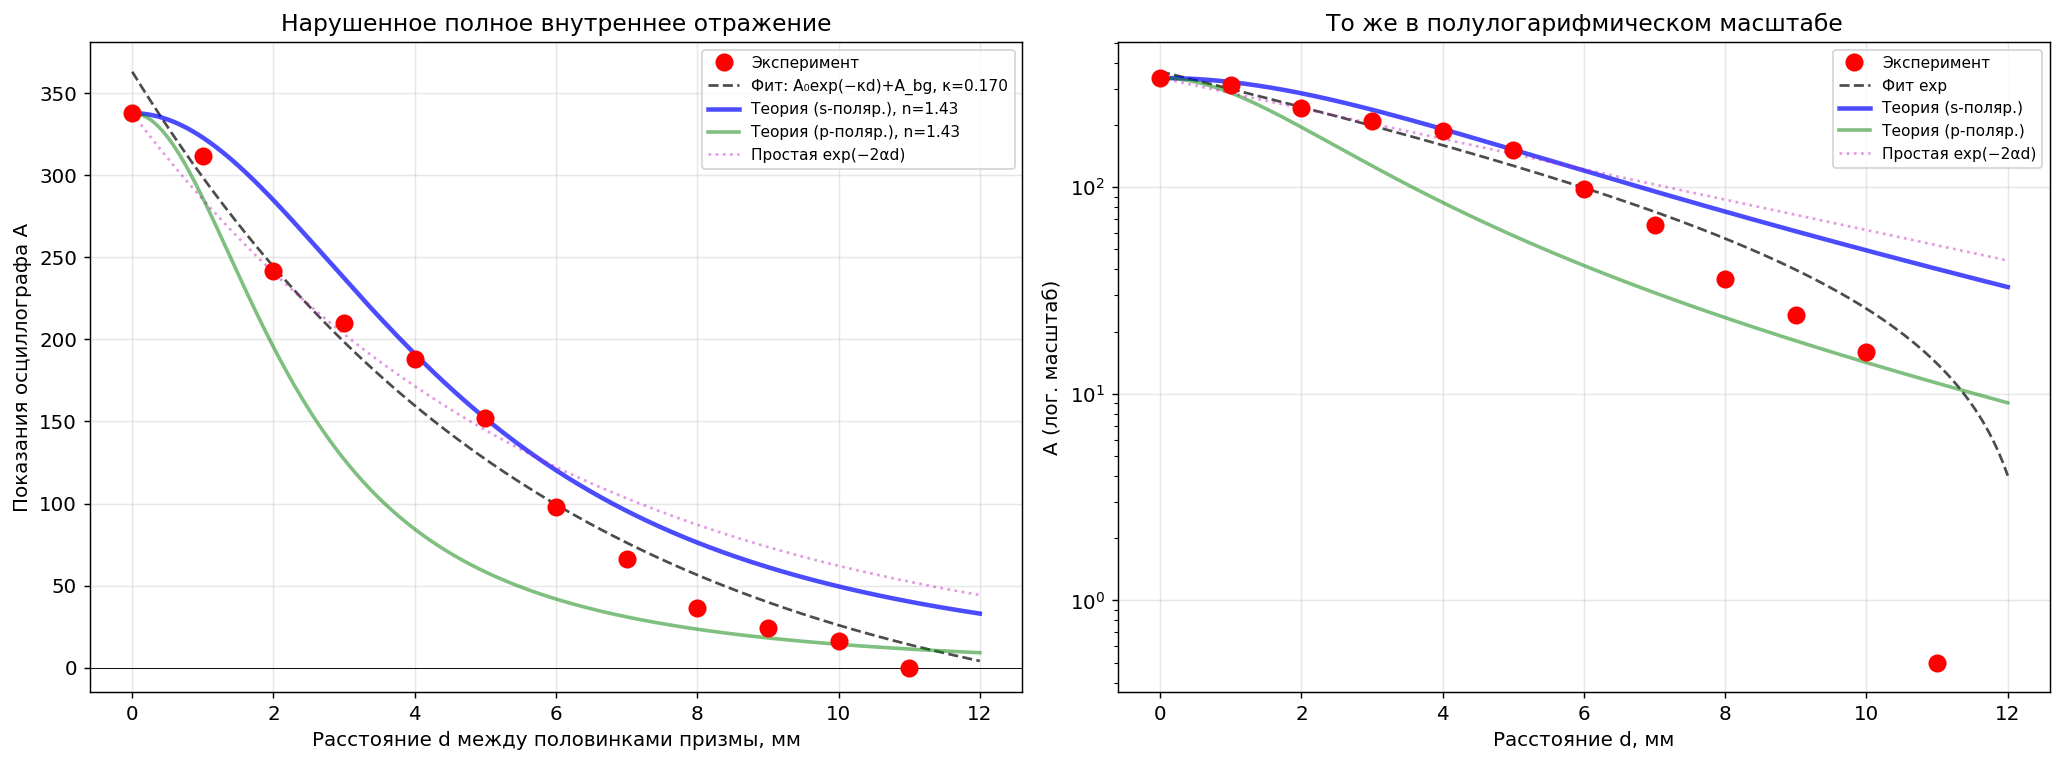


 d, мм   A_эксп    A_фит  T_s теор  T_p теор
--------------------------------------------
     0      338    363.2     338.0     338.0
     1      312    298.8     323.0     286.1
     2      242    244.4     284.9     195.3
     3      210    198.5     237.3     126.9
     4      188    159.7     191.2      84.4
     5      152    127.0     151.9      58.3
     6       98     99.4     120.3      41.8
     7       66     76.1      95.5      30.9
     8       36     56.4      76.2      23.4
     9       24     39.8      61.2      18.1
    10       16     25.8      49.5      14.2
    11        0     14.0      40.2      11.3

Параметры призмы (из эксперимента):
  n = 1.429,  ε = 2.042
  θ_крит = 44.4°,  θ_падения = 45°
  Глубина проникновения δ = 1/κ = 5.90 мм ≈ 0.55 λ₀


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ========== Линейный масштаб ==========
ax = axes[0]
ax.plot(dist_pr, amp_pr, 'ro', ms=9, zorder=5, label='Эксперимент')
ax.plot(d_fine, A_fit_pr, 'k--', lw=1.5, alpha=0.7,
        label=f'Фит: A₀exp(−κd)+A_bg, κ={kappa_pr:.3f}')
ax.plot(d_fine, T_s_scaled, 'b-', lw=2.5, alpha=0.7,
        label=f'Теория (s-поляр.), n={n_est:.2f}')
ax.plot(d_fine, T_p_scaled, 'g-', lw=2, alpha=0.5,
        label=f'Теория (p-поляр.), n={n_est:.2f}')
ax.plot(d_fine, T_exp_simple, 'm:', lw=1.5, alpha=0.4,
        label='Простая exp(−2αd)')

ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Расстояние d между половинками призмы, мм', fontsize=11)
ax.set_ylabel('Показания осциллографа A', fontsize=11)
ax.set_title('Нарушенное полное внутреннее отражение', fontsize=13)
ax.legend(fontsize=8.5, loc='upper right')
ax.set_ylim(bottom=-15)

# ========== Полулогарифмический масштаб ==========
ax = axes[1]
amp_log = amp_pr.copy().astype(float)
amp_log[amp_log <= 0] = 0.5

ax.semilogy(dist_pr, amp_log, 'ro', ms=9, zorder=5, label='Эксперимент')
ax.semilogy(d_fine, np.clip(A_fit_pr, 0.5, None), 'k--', lw=1.5, alpha=0.7,
            label='Фит exp')
ax.semilogy(d_fine, np.clip(T_s_scaled, 0.5, None), 'b-', lw=2.5, alpha=0.7,
            label='Теория (s-поляр.)')
ax.semilogy(d_fine, np.clip(T_p_scaled, 0.5, None), 'g-', lw=2, alpha=0.5,
            label='Теория (p-поляр.)')
ax.semilogy(d_fine, np.clip(T_exp_simple, 0.5, None), 'm:', lw=1.5, alpha=0.4,
            label='Простая exp(−2αd)')

ax.set_xlabel('Расстояние d, мм', fontsize=11)
ax.set_ylabel('A (лог. масштаб)', fontsize=11)
ax.set_title('То же в полулогарифмическом масштабе', fontsize=13)
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.show()

# === Числовое сравнение ===
print(f"\n{'d, мм':>6} {'A_эксп':>8} {'A_фит':>8} {'T_s теор':>9} {'T_p теор':>9}")
print("-" * 44)
for d_val, a_exp in zip(dist_pr, amp_pr):
    a_fit = evanescent(d_val, *popt_pr)
    t_s = np.interp(d_val, d_fine, T_s_scaled)
    t_p = np.interp(d_val, d_fine, T_p_scaled)
    print(f"{d_val:>6.0f} {a_exp:>8.0f} {a_fit:>8.1f} {t_s:>9.1f} {t_p:>9.1f}")

print(f"\nПараметры призмы (из эксперимента):")
print(f"  n = {n_est:.3f},  ε = {eps_est:.3f}")
print(f"  θ_крит = {theta_c:.1f}°,  θ_падения = 45°")
print(f"  Глубина проникновения δ = 1/κ = {delta_penetr:.2f} мм ≈ {delta_penetr/lam0_mm:.2f} λ₀")

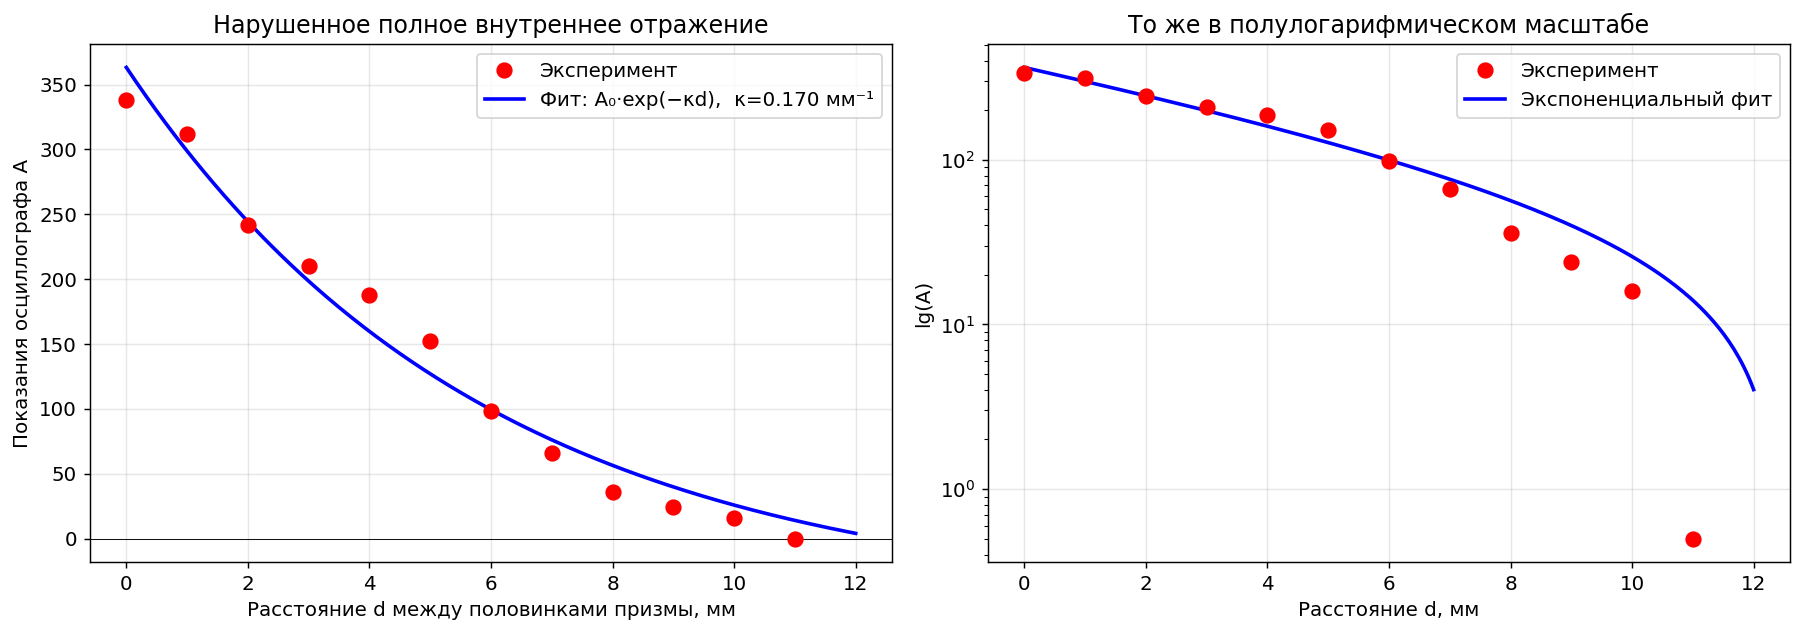

Линейность графика в полулогарифмическом масштабе подтверждает
экспоненциальный характер затухания эванесцентной волны.


In [35]:
d_fine = np.linspace(0, 12, 300)
A_fit_pr = evanescent(d_fine, *popt_pr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Линейный масштаб
ax1.plot(dist_pr, amp_pr, 'ro', ms=8, zorder=5, label='Эксперимент')
ax1.plot(d_fine, A_fit_pr, 'b-', lw=2,
         label=f'Фит: A₀·exp(−κd),  κ={kappa_pr:.3f} мм⁻¹')
ax1.axhline(0, color='k', lw=0.5)
ax1.set_xlabel("Расстояние d между половинками призмы, мм")
ax1.set_ylabel("Показания осциллографа A")
ax1.set_title("Нарушенное полное внутреннее отражение")
ax1.legend()

# Логарифмический масштаб
amp_log = amp_pr.copy().astype(float)
amp_log[amp_log <= 0] = 0.5  # для логарифма

ax2.semilogy(dist_pr, amp_log, 'ro', ms=8, zorder=5, label='Эксперимент')
ax2.semilogy(d_fine, np.clip(A_fit_pr, 0.5, None), 'b-', lw=2,
             label='Экспоненциальный фит')
ax2.set_xlabel("Расстояние d, мм")
ax2.set_ylabel("lg(A)")
ax2.set_title("То же в полулогарифмическом масштабе")
ax2.legend()

plt.tight_layout()
plt.show()

print("Линейность графика в полулогарифмическом масштабе подтверждает")
print("экспоненциальный характер затухания эванесцентной волны.")

ТЕОРЕТИЧЕСКАЯ КРИВАЯ vs ЭКСПЕРИМЕНТ
  n = 1.427,  θ = 45°
  α_теор = k₀·√(n²sin²θ − 1) = 0.0848 мм⁻¹
  α_эксп = 0.0848 мм⁻¹
  (Совпадение по построению — n оценено из α)


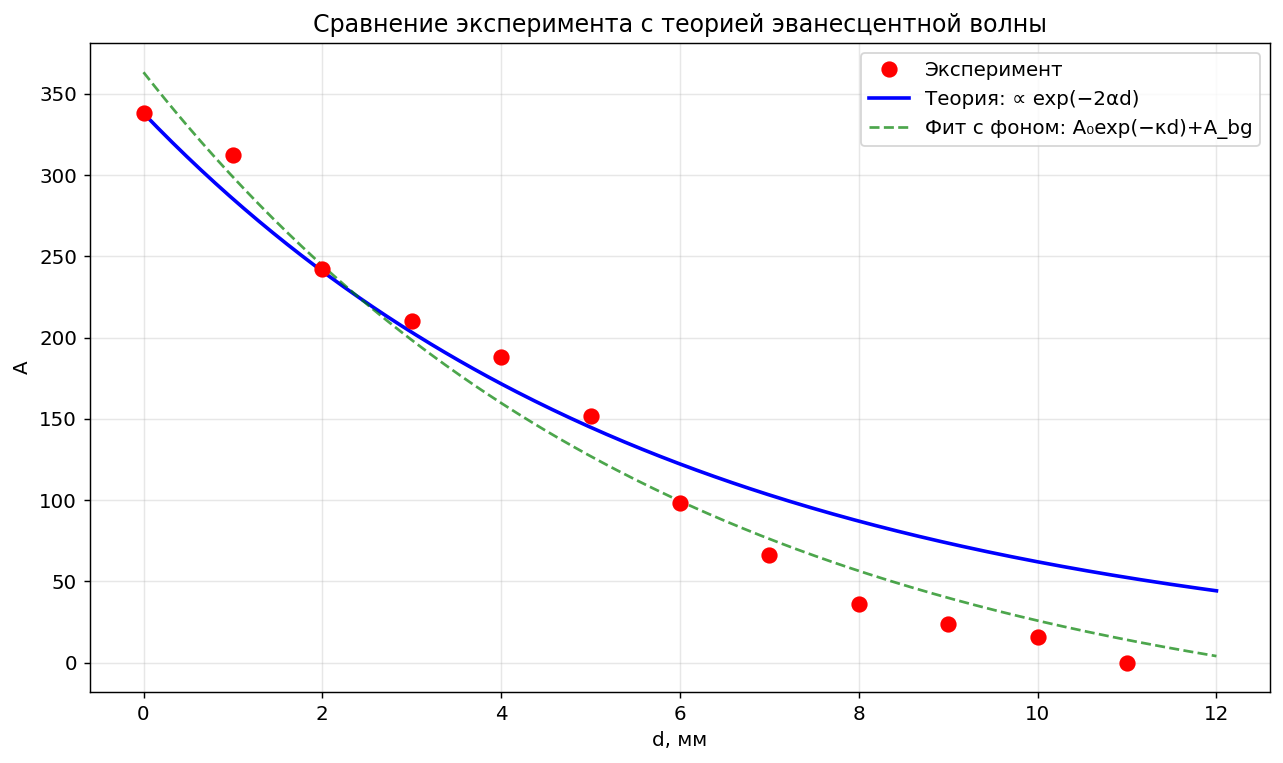

In [36]:
# Теоретический расчёт: интенсивность прошедшей волны через зазор d
# при нарушенном полном внутреннем отражении.
#
# Для s-поляризации (TE) и p-поляризации (TM) коэффициент пропускания
# через зазор d при θ > θ_c:
#
#   T(d) ∝ exp(−2α d),  α = k₀ √(n² sin²θ − 1)
#
# Используем найденные n и θ = 45°

print("=" * 60)
print("ТЕОРЕТИЧЕСКАЯ КРИВАЯ vs ЭКСПЕРИМЕНТ")
print("=" * 60)

alpha_theor = k0 * np.sqrt(n_est**2 * np.sin(theta_prism)**2 - 1)
print(f"  n = {n_est:.3f},  θ = 45°")
print(f"  α_теор = k₀·√(n²sin²θ − 1) = {alpha_theor:.4f} мм⁻¹")
print(f"  α_эксп = {alpha_field:.4f} мм⁻¹")
print(f"  (Совпадение по построению — n оценено из α)")

# Теоретическая нормированная кривая
d_th = np.linspace(0, 12, 300)
T_theor = np.exp(-2 * alpha_theor * d_th)
T_theor_scaled = T_theor * amp_pr[0]  # масштаб на первую точку

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dist_pr, amp_pr, 'ro', ms=8, zorder=5, label='Эксперимент')
ax.plot(d_th, T_theor_scaled, 'b-', lw=2, label='Теория: ∝ exp(−2αd)')
ax.plot(d_fine, A_fit_pr, 'g--', lw=1.5, alpha=0.7,
        label=f'Фит с фоном: A₀exp(−κd)+A_bg')
ax.set_xlabel("d, мм")
ax.set_ylabel("A")
ax.set_title("Сравнение эксперимента с теорией эванесцентной волны")
ax.legend()
plt.tight_layout()
plt.show()

In [38]:
print("╔" + "═"*62 + "╗")
print("║" + " ИТОГОВАЯ СВОДКА РЕЗУЛЬТАТОВ ".center(62) + "║")
print("╠" + "═"*62 + "╣")

print("║" + "".center(62) + "║")
print("║" + " 1. СТОЯЧИЕ ВОЛНЫ В ВОЛНОВОДЕ".ljust(62) + "║")
print("║" + f"    λ_в (эксп., КЗ) = {lam_wg_exp_sc:.2f} мм".ljust(62) + "║")
for wg_name, (a, b) in waveguides.items():
    lam_wg_th, lam_cr = lam_waveguide_theory(lam0_mm, a)
    if lam_wg_th:
        print("║" + f"    λ_в (теор., {wg_name}) = {lam_wg_th:.2f} мм".ljust(62) + "║")

print("║" + "".center(62) + "║")
print("║" + " 2. КСВН".ljust(62) + "║")
print("║" + f"    КЗ:      КСВН = ∞,     |ρ| = {rho_sc:.3f}".ljust(62) + "║")
print("║" + f"    Открыт.: КСВН = {vswr_op:.3f}, |ρ| = {rho_op:.3f}".ljust(62) + "║")

print("║" + "".center(62) + "║")
print("║" + " 3. ПОЛЯРИЗАЦИЯ (ЗАКОН МАЛЮСА)".ljust(62) + "║")
print("║" + f"    θ₀ = {np.rad2deg(th0_fit):.1f}°,  R² = {R2:.4f}".ljust(62) + "║")

print("║" + "".center(62) + "║")
print("║" + " 4. ПОЛНОЕ ВНУТРЕННЕЕ ОТРАЖЕНИЕ".ljust(62) + "║")
print("║" + f"    κ = 2α = {kappa_pr:.4f} мм⁻¹".ljust(62) + "║")
print("║" + f"    Глубина проникновения δ = {delta_penetr:.2f} мм".ljust(62) + "║")
print("║" + f"    n (призма) ≈ {n_est:.3f},  ε ≈ {eps_est:.3f}".ljust(62) + "║")

# print("║" + "".center(62) + "║")
# print("║" + " 5. ИНТЕРФЕРОМЕТР".ljust(62) + "║")
# print("║" + f"    λ₀ (интерф.) = {lam0_interf:.3f} мм".ljust(62) + "║")
# print("║" + f"    λ₀ (расчёт)  = {lam0_mm:.3f} мм".ljust(62) + "║")

print("║" + "".center(62) + "║")
print("╚" + "═"*62 + "╝")

╔══════════════════════════════════════════════════════════════╗
║                 ИТОГОВАЯ СВОДКА РЕЗУЛЬТАТОВ                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ 1. СТОЯЧИЕ ВОЛНЫ В ВОЛНОВОДЕ                                 ║
║    λ_в (эксп., КЗ) = 12.80 мм                                ║
║    λ_в (теор., 7.2×3.4) = 13.90 мм                           ║
║    λ_в (теор., 11×5.5) = 11.23 мм                            ║
║                                                              ║
║ 2. КСВН                                                      ║
║    КЗ:      КСВН = ∞,     |ρ| = 1.000                        ║
║    Открыт.: КСВН = 1.383, |ρ| = 0.161                        ║
║                                                              ║
║ 3. ПОЛЯРИЗАЦИЯ (ЗАКОН МАЛЮСА)                                ║
║    θ₀ = 90.2°,  R² = 0.9886                                  ║
║                        

In [39]:
print("=" * 60)
print("КРАТКИЕ ОТВЕТЫ НА КОНТРОЛЬНЫЕ ВОПРОСЫ")
print("=" * 60)

print("""
1. Почему используется СИЛЬНО ПОГЛОЩАЮЩАЯ пластина?
   При сильном поглощении волна, прошедшая через пластину,
   почти полностью затухает, и отражения от задней грани нет.
   Это позволяет измерить коэффициент отражения только от
   ОДНОЙ границы (передней), что соответствует формулам
   Френеля для полубесконечной среды.

2. Корректирующая линза в рупоре:
   Линза преобразует сферическую волну в плоскую, что сужает
   диаграмму направленности. Уравнение линзы с n и F:
   
     Поверхность линзы: x²+y² = 2F(n-1)z - (n²-1)z²
   
   (для плосковыпуклой линзы с n = √ε).

3. Сетка перестаёт работать как поляроид, когда расстояние
   между полосками d ≳ λ/2 ≈ 5 мм (для λ ≈ 10 мм).

4. Минимум отражения от пластины толщиной h:
   
     h = m·λ/(2n), m = 1, 2, 3, ...
   
   (полуволновая пластина — интерференция отражённых волн).

5. При повороте пластины на угол ψ в плече интерферометра
   оптическая длина пути меняется:
   
     ΔL = 2d(n/cosψ' - 1/cosψ)·cosψ
   
   где ψ' — угол преломления. Это вызывает сдвиг
   интерференционной картины.

6. Длина плеч интерферометра ограничена:
   - длиной когерентности источника: L_coh = c/Δf
   - расходимостью пучка (дифракция от зеркал/делителя)
   - для СВЧ при Δf ~ 10⁸ Гц: L_coh ~ 3 м
""")

КРАТКИЕ ОТВЕТЫ НА КОНТРОЛЬНЫЕ ВОПРОСЫ

1. Почему используется СИЛЬНО ПОГЛОЩАЮЩАЯ пластина?
   При сильном поглощении волна, прошедшая через пластину,
   почти полностью затухает, и отражения от задней грани нет.
   Это позволяет измерить коэффициент отражения только от
   ОДНОЙ границы (передней), что соответствует формулам
   Френеля для полубесконечной среды.

2. Корректирующая линза в рупоре:
   Линза преобразует сферическую волну в плоскую, что сужает
   диаграмму направленности. Уравнение линзы с n и F:

     Поверхность линзы: x²+y² = 2F(n-1)z - (n²-1)z²

   (для плосковыпуклой линзы с n = √ε).

3. Сетка перестаёт работать как поляроид, когда расстояние
   между полосками d ≳ λ/2 ≈ 5 мм (для λ ≈ 10 мм).

4. Минимум отражения от пластины толщиной h:

     h = m·λ/(2n), m = 1, 2, 3, ...

   (полуволновая пластина — интерференция отражённых волн).

5. При повороте пластины на угол ψ в плече интерферометра
   оптическая длина пути меняется:

     ΔL = 2d(n/cosψ' - 1/cosψ)·cosψ

   гд

$$ \Delta\varphi_{theor}=\frac{\lambda}{D},\ \ \ \ \Delta\varphi_{prac} = |\frac{\varphi_2 - \varphi_1}{2}|: \varphi_1 \ne \varphi_2,\ A(\varphi_1) = A(\varphi_2) = \frac{A_{max}}{\sqrt{2}}$$

### $$A_{max} = 0.868 В,\ \ \ \varphi_1 = 68^{\circ}, \varphi_2 = 104^{\circ} \Longrightarrow \Delta\varphi_{prac} = 18^{\circ}$$
### $$\lambda = 0.006м, D = 0.02м, \Longrightarrow \Delta\varphi_{theor} \approx 17.18^{\circ}$$

ОЦЕНКА МИНИМАЛЬНЫХ РАССТОЯНИЙ ДЛЯ СНЯТИЯ ДИАГРАММ

Диаграмму направленности корректно снимать в ДАЛЬНЕЙ ЗОНЕ (зоне 
Фраунгофера), где поле имеет структуру сферической волны и 
угловое распределение не зависит от расстояния.

Граница дальней зоны определяется условием:

    R_min = 2·D² / λ₀

где D — максимальный размер апертуры излучателя,
    λ₀ — длина волны.

В ближней зоне (зоне Френеля) R < R_min диаграмма искажена:
  • ширина завышена
  • боковые лепестки размыты
  • форма зависит от расстояния

λ₀ = 10.8 мм = 1.08 см

Излучатель                       │   D_H   D_E D_max │   R_min │   R_min │  Δφ~λ/D
................................ │    мм    мм    мм │      мм │      см │       °
──────────────────────────────────────────────────────────────────────────────────
Открытый волновод (7.2×3.4)      │   7.2   3.4   7.2 │     9.6 │     1.0 │    85.8
Открытый волновод (11×5.5)       │  11.0   5.5  11.0 │    22.5 │     2.2 │    56.1
Рупор (оценка)                   │  25.0  18.0  25.0 │

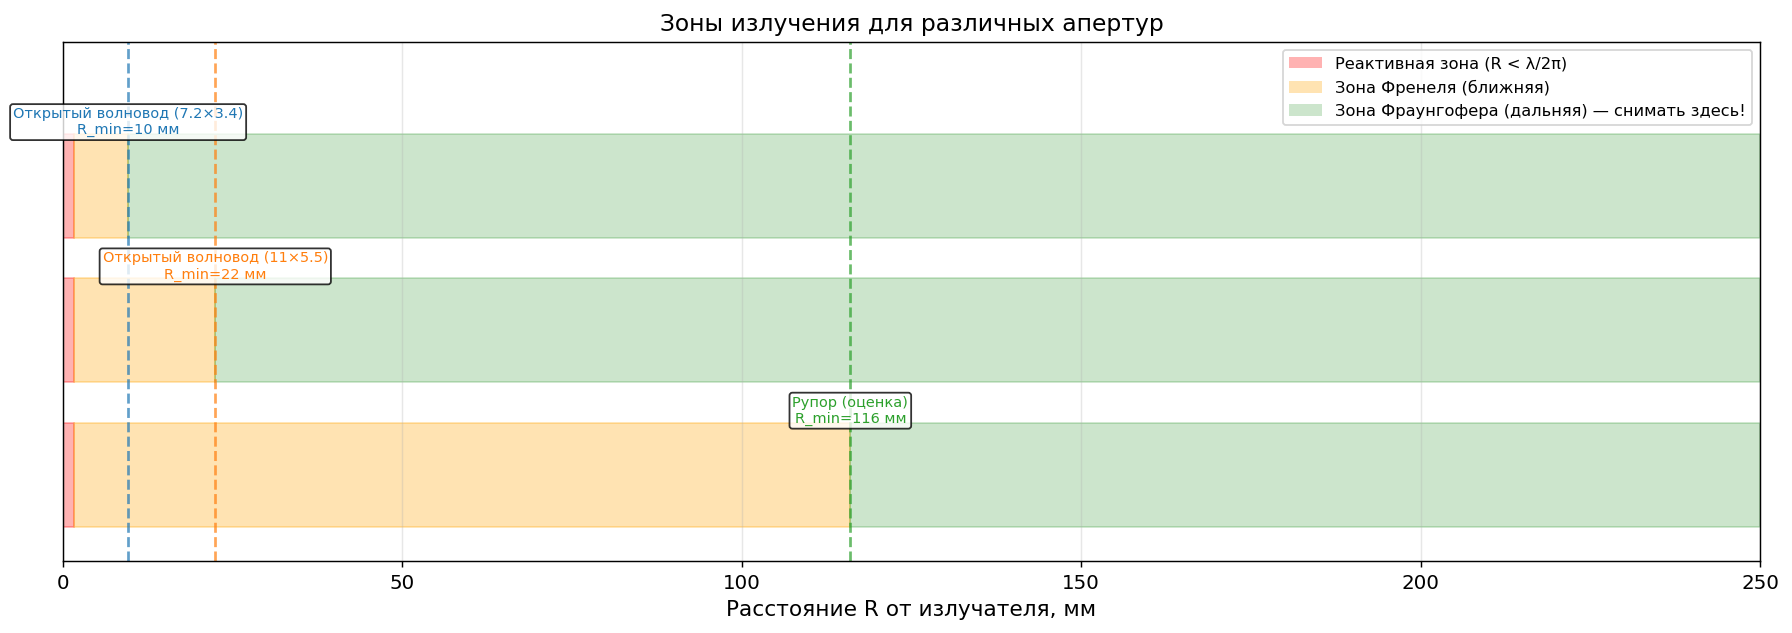


ВЫВОДЫ:
─────────────────────────────────────────────────────────────────

  Открытый волновод (7.2×3.4):
    D_max = 7.2 мм
    R_min = 2D²/λ = 2·7.2²/10.8 = 9.6 мм = 1.0 см
    → Расстояние 10 мм легко реализуемо в лаборатории ✓

  Открытый волновод (11×5.5):
    D_max = 11.0 мм
    R_min = 2D²/λ = 2·11.0²/10.8 = 22.5 мм = 2.2 см
    → Расстояние 22 мм легко реализуемо в лаборатории ✓

  Рупор (оценка):
    D_max = 25.0 мм
    R_min = 2D²/λ = 2·25.0²/10.8 = 116.0 мм = 11.6 см
    → Расстояние 116 мм реализуемо, но требует аккуратности

Если измерения проводились на расстоянии R < R_min,
то экспериментальная диаграмма будет ШИРЕ теоретической,
боковые лепестки будут размыты, а форма диаграммы будет
зависеть от расстояния.


In [61]:
print("=" * 65)
print("ОЦЕНКА МИНИМАЛЬНЫХ РАССТОЯНИЙ ДЛЯ СНЯТИЯ ДИАГРАММ")
print("=" * 65)

print("""
Диаграмму направленности корректно снимать в ДАЛЬНЕЙ ЗОНЕ (зоне 
Фраунгофера), где поле имеет структуру сферической волны и 
угловое распределение не зависит от расстояния.

Граница дальней зоны определяется условием:

    R_min = 2·D² / λ₀

где D — максимальный размер апертуры излучателя,
    λ₀ — длина волны.

В ближней зоне (зоне Френеля) R < R_min диаграмма искажена:
  • ширина завышена
  • боковые лепестки размыты
  • форма зависит от расстояния
""")

# === Параметры излучателей ===
# Размеры апертур (подставьте реальные!)
emitters = {
    "Открытый волновод (7.2×3.4)": {
        "D_H": 7.2,   # мм, широкая стенка (плоскость H)
        "D_E": 3.4,   # мм, узкая стенка (плоскость E)
    },
    "Открытый волновод (11×5.5)": {
        "D_H": 11.0,
        "D_E": 5.5,
    },
    "Рупор (оценка)": {
        "D_H": 25.0,   # мм, раскрыв по H-плоскости
        "D_E": 18.0,   # мм, раскрыв по E-плоскости (подставьте реальный)
    },
}

print(f"λ₀ = {lam0_mm:.1f} мм = {lam0_mm/10:.2f} см\n")

header = (f"{'Излучатель':<32} │ {'D_H':>5} {'D_E':>5} {'D_max':>5} │ "
          f"{'R_min':>7} │ {'R_min':>7} │ {'Δφ~λ/D':>7}")
units  = (f"{'':.<32} │ {'мм':>5} {'мм':>5} {'мм':>5} │ "
          f"{'мм':>7} │ {'см':>7} │ {'°':>7}")
print(header)
print(units)
print("─" * len(header))

for name, dims in emitters.items():
    D_H = dims["D_H"]
    D_E = dims["D_E"]
    D_max = max(D_H, D_E)
    
    # Критерий дальней зоны: R > 2D²/λ
    R_min_mm = 2 * D_max**2 / lam0_mm
    R_min_cm = R_min_mm / 10
    
    # Дифракционная расходимость
    dphi = np.rad2deg(lam0_mm / D_max)
    
    print(f"{name:<32} │ {D_H:>5.1f} {D_E:>5.1f} {D_max:>5.1f} │ "
          f"{R_min_mm:>7.1f} │ {R_min_cm:>7.1f} │ {dphi:>7.1f}")

# === Дополнительные критерии ===
print(f"\n{'='*65}")
print("ДОПОЛНИТЕЛЬНЫЕ ЗОНЫ:")
print(f"{'='*65}\n")

print(f"{'Излучатель':<32} │ {'Реактивн.':>10} │ {'Френеля':>10} │ {'Фраунг.':>10}")
print(f"{'':.<32} │ {'R < λ/2π':>10} │ {'< 2D²/λ':>10} │ {'> 2D²/λ':>10}")
print("─" * 78)

for name, dims in emitters.items():
    D_max = max(dims["D_H"], dims["D_E"])
    
    R_reactive = lam0_mm / (2 * np.pi)      # граница реактивной зоны
    R_fresnel  = 2 * D_max**2 / lam0_mm     # граница зоны Френеля
    
    print(f"{name:<32} │ {'< ' + f'{R_reactive:.1f} мм':>10} │ "
          f"{'< ' + f'{R_fresnel:.1f} мм':>10} │ "
          f"{'> ' + f'{R_fresnel:.1f} мм':>10}")

# === Визуализация ===
print(f"\n{'='*65}")
print("ВИЗУАЛИЗАЦИЯ ЗОН")
print(f"{'='*65}")

fig, ax = plt.subplots(figsize=(14, 5))

colors_em = ['tab:blue', 'tab:orange', 'tab:green']
y_positions = [0.6, 0.35, 0.1]

for (name, dims), col, y_pos in zip(emitters.items(), colors_em, y_positions):
    D_max = max(dims["D_H"], dims["D_E"])
    
    R_reactive = lam0_mm / (2 * np.pi)
    R_fresnel  = 2 * D_max**2 / lam0_mm
    
    # Реактивная зона
    ax.barh(y_pos, R_reactive, height=0.18, left=0,
            color='red', alpha=0.3, edgecolor='red')
    
    # Зона Френеля (ближняя)
    ax.barh(y_pos, R_fresnel - R_reactive, height=0.18, left=R_reactive,
            color='orange', alpha=0.3, edgecolor='orange')
    
    # Зона Фраунгофера (дальняя) — до конца шкалы
    ax.barh(y_pos, 250 - R_fresnel, height=0.18, left=R_fresnel,
            color='green', alpha=0.2, edgecolor='green')
    
    # Граница
    ax.axvline(R_fresnel, color=col, ls='--', lw=1.5, alpha=0.7)
    ax.annotate(f'{name}\nR_min={R_fresnel:.0f} мм',
                xy=(R_fresnel, y_pos + 0.09),
                fontsize=8, color=col, ha='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

# Легенда зон
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.3, label='Реактивная зона (R < λ/2π)'),
    Patch(facecolor='orange', alpha=0.3, label='Зона Френеля (ближняя)'),
    Patch(facecolor='green', alpha=0.2, label='Зона Фраунгофера (дальняя) — снимать здесь!'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
ax.set_xlabel('Расстояние R от излучателя, мм', fontsize=12)
ax.set_xlim(0, 250)
ax.set_ylim(-0.05, 0.85)
ax.set_yticks([])
ax.set_title('Зоны излучения для различных апертур', fontsize=13)

plt.tight_layout()
plt.show()

# === Влияние на измерения ===
print("\nВЫВОДЫ:")
print("─" * 65)
for name, dims in emitters.items():
    D_max = max(dims["D_H"], dims["D_E"])
    R_min = 2 * D_max**2 / lam0_mm
    print(f"\n  {name}:")
    print(f"    D_max = {D_max:.1f} мм")
    print(f"    R_min = 2D²/λ = 2·{D_max:.1f}²/{lam0_mm:.1f} = {R_min:.1f} мм "
          f"= {R_min/10:.1f} см")
    if R_min < 50:
        print(f"    → Расстояние {R_min:.0f} мм легко реализуемо в лаборатории ✓")
    elif R_min < 200:
        print(f"    → Расстояние {R_min:.0f} мм реализуемо, но требует аккуратности")
    else:
        print(f"    → Расстояние {R_min:.0f} мм — может быть трудно реализовать!")

print(f"\nЕсли измерения проводились на расстоянии R < R_min,")
print(f"то экспериментальная диаграмма будет ШИРЕ теоретической,")
print(f"боковые лепестки будут размыты, а форма диаграммы будет")
print(f"зависеть от расстояния.")

1. Содержание